# Практична робота 04: Проєктування рішення навколо фіксованого класифікатора

## Набір даних Hill-Valley (UCI)

Мета: зафіксувати модель, отримати OOF-бали, підготувати основу для аналізу порогів.

**Увага:** на цьому етапі ми не виконуємо повний цикл (сітка порогів, калібрування, політика, test).
Лише фіксація протоколу та отримання OOF-балів.


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

### 1. Завантаження даних

Використовуємо `ucimlrepo` для отримання набору Hill-Valley (id=166).
Обираємо версію **без шуму** (Hill_Valley_without_noise) для чистоти експерименту.

In [3]:
import pandas as pd

# 1. Downloading file. adding header=None, 
hill_valley = pd.read_csv('Hill_Valley_without_noise_Training.data', header=None)

# 2. dividing data:
# iloc[:, :-1] takes all except last (cause it X)
X = hill_valley.iloc[:, :-1]

# iloc[:, -1] takes all except last (cause it y)
y = hill_valley.iloc[:, -1]

# 3. Outputing data
print('Форма X:', X.shape)
print('Форма y:', y.shape)
print('Розподіл класів:')
print(y.value_counts())
print('\nПерші 5 ознак:')
print(X.head())


Форма X: (607, 100)
Форма y: (607,)
Розподіл класів:
100
0        305
1        301
class      1
Name: count, dtype: int64

Перші 5 ознак:
            0            1            2            3            4   \
0           X1           X2           X3           X4           X5   
1  1317.265789  1315.220951  1312.770581  1309.834252  1306.315588   
2  7329.967624  7379.907443  7441.799231  7518.503422  7613.565031   
3  809.4214096  809.7801194  810.2071911  810.7156529   811.321016   
4  45334.20888  45334.21356  45334.21906   45334.2255  45334.23305   

            5            6            7            8            9   ...  \
0           X6           X7           X8           X9          X10  ...   
1  1302.099102  1297.046401  1290.991646  1283.736109  1275.041652  ...   
2  7731.377492  7877.385707  8058.337694  8282.596458  8560.526497  ...   
3  812.0417476  812.8998341  813.9214524   815.137768  816.5858856  ...   
4  45334.24191   45334.2523  45334.26448  45334.27876  45334.29552

### 2. Фіксація train/test split та random_state

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split


hill_valley = pd.read_csv('Hill_Valley_without_noise_Training.data') 


X = hill_valley.iloc[:, :-1]
y = hill_valley.iloc[:, -1]


RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Розподіл класів у train:')
print(y_train.value_counts(normalize=True))
print('Розподіл класів у test:')
print(y_test.value_counts(normalize=True))


Train: (484, 100) Test: (122, 100)
Розподіл класів у train:
class
0    0.504132
1    0.495868
Name: proportion, dtype: float64
Розподіл класів у test:
class
1    0.5
0    0.5
Name: proportion, dtype: float64


### 3. Фіксована модель та Pipeline

Обираємо **LogisticRegression** як базовий класифікатор.
Preprocessing: StandardScaler у Pipeline.
Гіперпараметри: `C=1.0`, `solver='lbfgs'`, `max_iter=1000`.

Якщо у вашій лабораторній роботі №2 використовувалась інша модель (наприклад, RandomForest),
замініть її тут, але зафіксуйте всі параметри.

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
])

print('Pipeline зафіксовано:')
print(pipeline)

Pipeline зафіксовано:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])


### 4. Стратифікована крос-валідація та OOF-бали

Використовуємо `StratifiedKFold` з 5 фолдами.
Спосіб отримання балу: `predict_proba` (ймовірність класу 1).

Для кожного об'єкта тренувального набору отримуємо прогноз від моделі,
яка не навчалася на цьому об'єкті.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Отримуємо OOF-ймовірності для всього train набору
oof_scores = cross_val_predict(
    pipeline, X_train, y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]  # ймовірність класу 1 (hill)

# Перевіряємо, що кожен об'єкт має рівно один прогноз
assert len(oof_scores) == len(X_train), 'Кількість OOF-прогнозів не збігається з кількістю об\'єктів'

print('OOF-бали отримано. Приклад перших 10:')
print(oof_scores[:10])

OOF-бали отримано. Приклад перших 10:
[0.50952585 0.85534823 0.40540655 0.5083684  0.50832839 0.49829611
 0.52178756 0.50138154 0.49823641 0.50817557]


### 5. Формування таблиці OOF

Створюємо DataFrame з полями: `object_id`, `y_true`, `score`, `fold`.
`object_id` — індекс об'єкта у вихідному train наборі (0..N-1).
`fold` — номер фолду, у якому об'єкт був у валідаційній частині.

In [7]:
# Визначаємо fold для кожного об'єкта
fold_ids = np.zeros(len(X_train), dtype=int)
for fold_idx, (_, val_idx) in enumerate(cv.split(X_train, y_train)):
    fold_ids[val_idx] = fold_idx

oof_df = pd.DataFrame({
    'object_id': np.arange(len(X_train)),
    'y_true': y_train.values.ravel(),
    'score': oof_scores,
    'fold': fold_ids
})

print('Форма OOF-таблиці:', oof_df.shape)
print(oof_df.head(10))
print('\nРозподіл по фолдах:')
print(oof_df['fold'].value_counts().sort_index())

Форма OOF-таблиці: (484, 4)
   object_id  y_true     score  fold
0          0       1  0.509526     0
1          1       1  0.855348     0
2          2       0  0.405407     1
3          3       1  0.508368     1
4          4       0  0.508328     1
5          5       0  0.498296     2
6          6       0  0.521788     3
7          7       0  0.501382     4
8          8       0  0.498236     2
9          9       1  0.508176     2

Розподіл по фолдах:
fold
0    97
1    97
2    97
3    97
4    96
Name: count, dtype: int64


### 6. Базова оцінка OOF-балів

Обчислюємо ROC-AUC та accuracy за стандартним порогом 0.5.
Це проміжна оцінка, яка не є фінальною метрикою рішення.

In [8]:
roc_auc = roc_auc_score(oof_df['y_true'], oof_df['score'])
y_pred_default = (oof_df['score'] >= 0.5).astype(int)
acc = accuracy_score(oof_df['y_true'], y_pred_default)

print(f'OOF ROC-AUC: {roc_auc:.4f}')
print(f'OOF Accuracy (порог 0.5): {acc:.4f}')

OOF ROC-AUC: 0.7814
OOF Accuracy (порог 0.5): 0.6694


### 7. Збереження OOF-таблиці

Зберігаємо `oof_results.csv` у директорію `../data/` для подальшого аналізу.

In [9]:
import os
os.makedirs('data', exist_ok=True)
oof_df.to_csv('data/oof_results.csv', index=False)
print('OOF-таблицю збережено у ../data/oof_results.csv')

OOF-таблицю збережено у ../data/oof_results.csv


---

## Примітки

- `score` у таблиці — це ймовірність класу 1 (hill), отримана через `predict_proba`.
- `fold` вказує, у якому фолді об'єкт був у валідаційній вибірці.
- Наступні кроки (сітка порогів, аналіз FP/FN, калібрування) будуть виконані в окремих комірках або наступних ноутбуках.

---

# 3. Контрольна політика (baseline)

## 3.1. Вибір початкового порогу

Оскільки для отримання балів використано `predict_proba` моделі `LogisticRegression`,
значення `score` можна інтерпретувати як **калібровану ймовірність** (наближено).

Тому для **baseline-політики** обираємо стандартний поріг:

$$t_0 = 0.5$$

**Правило прийняття рішення:**
- якщо `score >= 0.5` → `ŷ = 1` (пагорб) → запускається дія
- якщо `score < 0.5` → `ŷ = 0` (долина) → дія не запускається

**Важливо:** test set на цьому етапі **не використовується**.
Усі обчислення — лише на OOF-балах тренувального набору.

In [10]:
# Фіксуємо baseline-поріг
t0 = 0.5

# Бінарні рішення за baseline-політикою
y_pred_baseline = (oof_df['score'] >= t0).astype(int)

print(f'Baseline поріг t0 = {t0}')
print(f'Кількість позитивних рішень (ŷ=1): {y_pred_baseline.sum()}')
print(f'Кількість негативних рішень (ŷ=0): {(1 - y_pred_baseline).sum()}')

Baseline поріг t0 = 0.5
Кількість позитивних рішень (ŷ=1): 340
Кількість негативних рішень (ŷ=0): 144


## 3.2. Матриця помилок (confusion matrix)

Обчислюємо матрицю помилок на OOF-прогнозах.
Порядок класів: `[0, 1]`, тобто:
- TN — правильно передбачена долина
- FP — хибно передбачений пагорб
- FN — пропущений пагорб
- TP — правильно передбачений пагорб

In [11]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(oof_df['y_true'], y_pred_baseline, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

print('Confusion matrix (рядки = true, стовпці = pred):')
print(pd.DataFrame(cm,
                   index=['True 0 (valley)', 'True 1 (hill)'],
                   columns=['Pred 0 (valley)', 'Pred 1 (hill)']))
print()
print(f'TN = {tn}')
print(f'FP = {fp}')
print(f'FN = {fn}')
print(f'TP = {tp}')

Confusion matrix (рядки = true, стовпці = pred):
                 Pred 0 (valley)  Pred 1 (hill)
True 0 (valley)              114            130
True 1 (hill)                 30            210

TN = 114
FP = 130
FN = 30
TP = 210


## 3.3. Метрики baseline-політики

Обчислюємо:
- **Precision** — частка правильних серед передбачених `ŷ=1`
- **Recall** — частка виявлених пагорбів серед усіх справжніх пагорбів
- **F1** — гармонійне середнє Precision і Recall
- **q(t)** — частка позитивних рішень (доля об'єктів, для яких запускається дія)
- **Дії на 1000 об'єктів** — скільки разів система запустить дію на кожні 1000 об'єктів

In [12]:
precision = precision_score(oof_df['y_true'], y_pred_baseline, pos_label=1)
recall = recall_score(oof_df['y_true'], y_pred_baseline, pos_label=1)
f1 = f1_score(oof_df['y_true'], y_pred_baseline, pos_label=1)

q_t = y_pred_baseline.mean()
actions_per_1000 = q_t * 1000

print('=== Метрики baseline-політики (t0 = 0.5) ===')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1        : {f1:.4f}')
print()
print(f'q(t0)     : {q_t:.4f}  ({q_t*100:.2f}%)')
print(f'Дій на 1000 об\'єктів: {actions_per_1000:.1f}')

=== Метрики baseline-політики (t0 = 0.5) ===
Precision : 0.6176
Recall    : 0.8750
F1        : 0.7241

q(t0)     : 0.7025  (70.25%)
Дій на 1000 об'єктів: 702.5


## 3.4. Прикладна інтерпретація baseline-політики

**Що означають отримані числа в контексті задачі:**

- **Precision** показує, наскільки можна довіряти позитивному рішенню `ŷ=1`.
  Якщо Precision = 0.95, то з 100 позначених «пагорбів» лише ~5 виявляться долинами.

- **Recall** показує, яку частку реальних пагорбів система взагалі виявляє.
  Якщо Recall = 0.85, то 15% пагорбів залишаються непоміченими (FN).

- **q(t0)** — це частка об'єктів, для яких запускається дія. Якщо q = 0.5,
  система позначає кожен другий об'єкт як «пагорб».

- **Дії на 1000 об'єктів** — практичний показник навантаження на систему
  (скільки разів буде активовано модуль подальшої обробки).

**Ключове питання для baseline:** чи влаштовує нас таке співвідношення FP і FN,
чи потрібно зміщувати поріг у бік зменшення одного з типів помилок?

Це питання буде вирішено в наступних розділах після побудови матриці вартостей.

---

# 4. Матриця вартостей

## 4.1. Таблиця наслідків для TN, FP, FN, TP

Для кожної комірки матриці помилок визначаємо:
1. **фактичний стан** об'єкта;
2. **рішення системи** (прогноз);
3. **операційну дію**, яку виконує система;
4. **можливий негативний або позитивний наслідок**;
5. **одиницю виміру** цього наслідку.

| Комірка | Факт | Рішення | Операційна дія | Наслідок | Одиниця виміру |
|---------|------|---------|----------------|----------|----------------|
| **TN** | Valley (0) | ŷ = 0 (valley) | Ділянка позначається як низовина; у маршруті враховується як безпечна | **Нейтральний / позитивний**: маршрут прокладено правильно, ресурси не витрачено даремно | Умовні одиниці витрат (0) |
| **FP** | Valley (0) | ŷ = 1 (hill) | Ділянка помилково позначається як пагорб; запускається додаткова обробка | **Негативний**: зайве ускладнення маршруту, витрати часу/ресурсів на обхід «пагорба», якого немає | Людино-години / хвилини обробки / умовні витрати |
| **FN** | Hill (1) | ŷ = 0 (valley) | Ділянка помилково позначається як низовина; маршрут прокладається напряму через неї | **Критично негативний**: потенційне зіткнення з рельєфом, пошкодження обладнання, загроза безпеці | Ймовірність аварії / вартість ремонту / ризик для життя |
| **TP** | Hill (1) | ŷ = 1 (hill) | Ділянка позначається як пагорб; маршрут коригується | **Позитивний**: безпечне проходження, коректна ідентифікація рельєфу | Умовні одиниці виграшу / збережені ресурси |

## 4.2. Визначення cFP та cFN

**Позначення:**
- $c_{FP}$ — вартість одного хибнопозитивного рішення (FP)
- $c_{FN}$ — вартість одного хибнонегативного рішення (FN)

**Ключове спостереження:**
У нашому прикладному контексті (аналіз рельєфу для автономного дрона / ГІС):

- **FP** → зайві витрати на обхід неіснуючого пагорба.
  Оцінка: **низька** (наприклад, 1 умовна одиниця).

- **FN** → пропущений пагорб → потенційне зіткнення.
  Оцінка: **висока** (наприклад, 10 умовних одиниць через ризик аварії).

**Відношення:**
$$\frac{c_{FN}}{c_{FP}} \approx 10$$

**Тип оцінки:**
- cFP — **суто сценарна** (експертна оцінка витрат на додаткову обробку).
- cFN — **експертна / нормативна** (базується на оцінці ризику для безпеки).

**Джерело / аргумент:**
- Для cFP: середній час оператора на перевірку одного об'єкта × вартість години.
- Для cFN: оцінка збитків від аварії (ремонт + простій + можливі штрафи).
- **ШІ не є джерелом реальної вартості** — це лише сценарне припущення для демонстрації методу.

**Важливо:** точні значення cFP і cFN мають бути узгоджені з замовником
або експертом предметної області. Тут вони наведені як **робоча гіпотеза**.

In [13]:
# Сценарні вартості (умовні одиниці)
c_FP = 1.0    # вартість одного FP
c_FN = 10.0   # вартість одного FN

# Очікувана вартість baseline-політики на OOF
expected_cost_baseline = fp * c_FP + fn * c_FN

# Нормалізована вартість на один об'єкт
cost_per_object = expected_cost_baseline / len(oof_df)

print('=== Оцінка вартості baseline-політики (t0 = 0.5) ===')
print(f'c_FP = {c_FP}, c_FN = {c_FN}')
print(f'FP = {fp}, FN = {fn}')
print(f'Очікувана сумарна вартість: {expected_cost_baseline:.1f} умовних одиниць')
print(f'Вартість на один об\'єкт: {cost_per_object:.4f}')
print()
print(f'Відношення c_FN / c_FP = {c_FN / c_FP:.1f}')
print()
print('Примітка: ці значення будуть використані для побудови сітки порогів')
print('та вибору політики, що мінімізує очікувану вартість.')

=== Оцінка вартості baseline-політики (t0 = 0.5) ===
c_FP = 1.0, c_FN = 10.0
FP = 130, FN = 30
Очікувана сумарна вартість: 430.0 умовних одиниць
Вартість на один об'єкт: 0.8884

Відношення c_FN / c_FP = 10.0

Примітка: ці значення будуть використані для побудови сітки порогів
та вибору політики, що мінімізує очікувану вартість.


## 4.3. Проміжний висновок

На цьому етапі ми маємо:

1. **Зафіксовану baseline-політику** з порогом `t0 = 0.5`.
2. **Метрики baseline**: Precision, Recall, F1, q(t), дії на 1000 об'єктів.
3. **Матрицю вартостей** з описаними наслідками TN, FP, FN, TP.
4. **Сценарні оцінки** cFP та cFN (з відношенням ~1:10).

**Наступні кроки:**
- Побудова **сітки порогів** `t ∈ [0, 1]`.
- Для кожного порогу — обчислення FP, FN, q(t) та очікуваної вартості.
- Вибір порогу, що мінімізує очікувану вартість (або задовольняє обмеження на Recall / Precision).
- **Калібрування** (за потреби) для покращення інтерпретації ймовірностей.
- **Одноразовий test** — лише після фіксації фінальної політики.

**Test set на цьому етапі не використовувався.**

In [16]:
# Зберігаємо результати baseline та вартості для подальшого аналізу
baseline_results = {
    'threshold': t0,
    'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'q_t': q_t,
    'actions_per_1000': actions_per_1000,
    'c_FP': c_FP,
    'c_FN': c_FN,
    'expected_cost': expected_cost_baseline,
    'cost_per_object': cost_per_object
}

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('data/baseline_policy.csv', index=False)
print('Результати baseline збережено у ../data/baseline_policy.csv')
print(baseline_df.T)

Результати baseline збережено у ../data/baseline_policy.csv
                           0
threshold           0.500000
TN                114.000000
FP                130.000000
FN                 30.000000
TP                210.000000
precision           0.617647
recall              0.875000
f1                  0.724138
q_t                 0.702479
actions_per_1000  702.479339
c_FP                1.000000
c_FN               10.000000
expected_cost     430.000000
cost_per_object     0.888430


---

# 5. Аналіз сітки порогів

## 5.1. Побудова сітки порогів

Будуємо сітку з **щонайменше 50 порогів**, що охоплює фактичний діапазон OOF-балів.

Для кожного порогу $t$ обчислюємо:
- $FP(t)$, $FN(t)$ — кількість хибнопозитивних і хибнонегативних рішень;
- $Precision(t)$, $Recall(t)$ — точність і повнота;
- $q(t)$ — частка позитивних рішень;
- $C(t)$ — очікувана вартість: $C(t) = c_{FP} \cdot FP(t) + c_{FN} \cdot FN(t)$.

**Діапазон балів:** від `min(score)` до `max(score)`.

In [17]:
# Діапазон OOF-балів
score_min = oof_df['score'].min()
score_max = oof_df['score'].max()
print(f'Мінімальний бал: {score_min:.6f}')
print(f'Максимальний бал: {score_max:.6f}')

# Сітка з 100 порогів (щонайменше 50 за вимогою)
n_thresholds = 100
thresholds = np.linspace(score_min, score_max, n_thresholds)

# Додаємо "граничні" пороги для перевірки крайніх випадків
thresholds = np.unique(np.concatenate([
    thresholds,
    [score_min - 1e-6, score_max + 1e-6, 0.5]
]))

print(f'Кількість порогів у сітці: {len(thresholds)}')
print(f'Перші 5: {thresholds[:5]}')
print(f'Останні 5: {thresholds[-5:]}')

Мінімальний бал: 0.003215
Максимальний бал: 0.992360
Кількість порогів у сітці: 103
Перші 5: [0.0032137  0.0032147  0.01320607 0.02319744 0.03318881]
Останні 5: [0.96238606 0.97237743 0.9823688  0.99236017 0.99236117]


In [18]:
def evaluate_threshold(y_true, scores, t, c_fp, c_fn):
    """Обчислює метрики для одного порогу t."""
    y_pred = (scores >= t).astype(int)
    
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    q_t       = y_pred.mean()
    cost      = c_fp * fp + c_fn * fn
    
    return {
        'threshold': t,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'q_t': q_t,
        'actions_per_1000': q_t * 1000,
        'cost': cost,
        'cost_per_object': cost / len(y_true)
    }

# Обчислюємо метрики для всіх порогів (використовуємо baseline c_FP, c_FN)
y_true_arr = oof_df['y_true'].values
scores_arr = oof_df['score'].values

grid_results = [evaluate_threshold(y_true_arr, scores_arr, t, c_FP, c_FN)
                for t in thresholds]

grid_df = pd.DataFrame(grid_results)
print('Форма сітки:', grid_df.shape)
print(grid_df.head())

Форма сітки: (103, 12)
   threshold  TN   FP  FN   TP  precision  recall        f1       q_t  \
0   0.003214   0  244   0  240   0.495868     1.0  0.662983  1.000000   
1   0.003215   0  244   0  240   0.495868     1.0  0.662983  1.000000   
2   0.013206   1  243   0  240   0.496894     1.0  0.663900  0.997934   
3   0.023197   2  242   0  240   0.497925     1.0  0.664820  0.995868   
4   0.033189   2  242   0  240   0.497925     1.0  0.664820  0.995868   

   actions_per_1000   cost  cost_per_object  
0       1000.000000  244.0         0.504132  
1       1000.000000  244.0         0.504132  
2        997.933884  243.0         0.502066  
3        995.867769  242.0         0.500000  
4        995.867769  242.0         0.500000  


In [19]:
# Зберігаємо CSV з усіма кандидатними порогами
grid_df.to_csv('data/threshold_grid.csv', index=False)
print('Сітку порогів збережено у ../data/threshold_grid.csv')

Сітку порогів збережено у ../data/threshold_grid.csv


## 5.2. Графік Precision та Recall від порога

Показує, як змінюються Precision і Recall при зміні порогу.
Зазвичай при збільшенні порогу Precision зростає, а Recall падає.

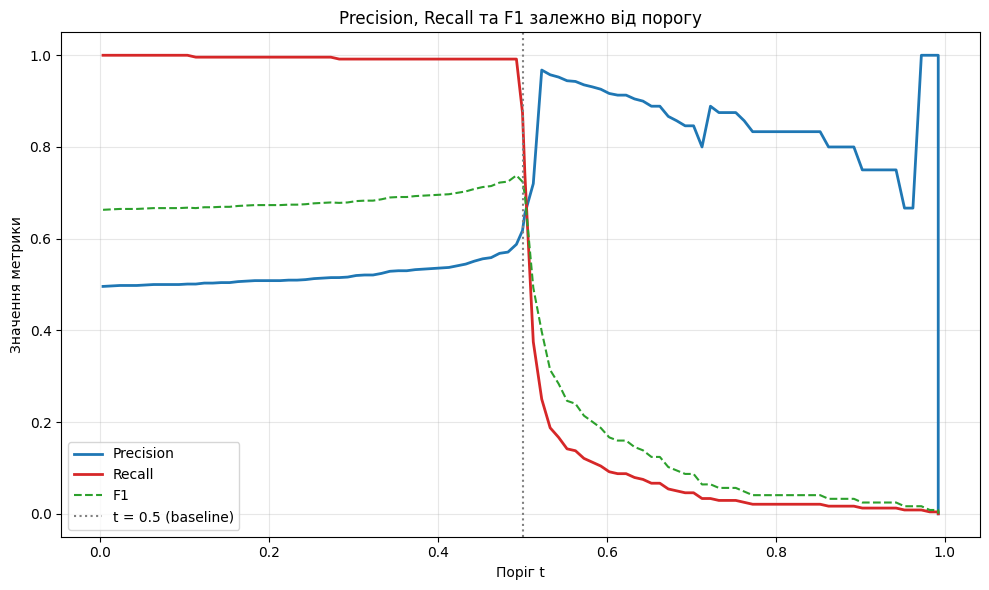

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(grid_df['threshold'], grid_df['precision'],
        label='Precision', color='tab:blue', linewidth=2)
ax.plot(grid_df['threshold'], grid_df['recall'],
        label='Recall', color='tab:red', linewidth=2)
ax.plot(grid_df['threshold'], grid_df['f1'],
        label='F1', color='tab:green', linewidth=1.5, linestyle='--')

ax.axvline(0.5, color='gray', linestyle=':', label='t = 0.5 (baseline)')

ax.set_xlabel('Поріг t')
ax.set_ylabel('Значення метрики')
ax.set_title('Precision, Recall та F1 залежно від порогу')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/precision_recall_vs_threshold.png', dpi=120)
plt.show()

## 5.3. Графік частки позитивних рішень q(t)

Показує, яка частка об'єктів буде позначена як «пагорб» (`ŷ=1`)
при кожному порозі. Це прямо пов'язано з навантаженням на систему
(кількість дій на 1000 об'єктів = q(t) × 1000).

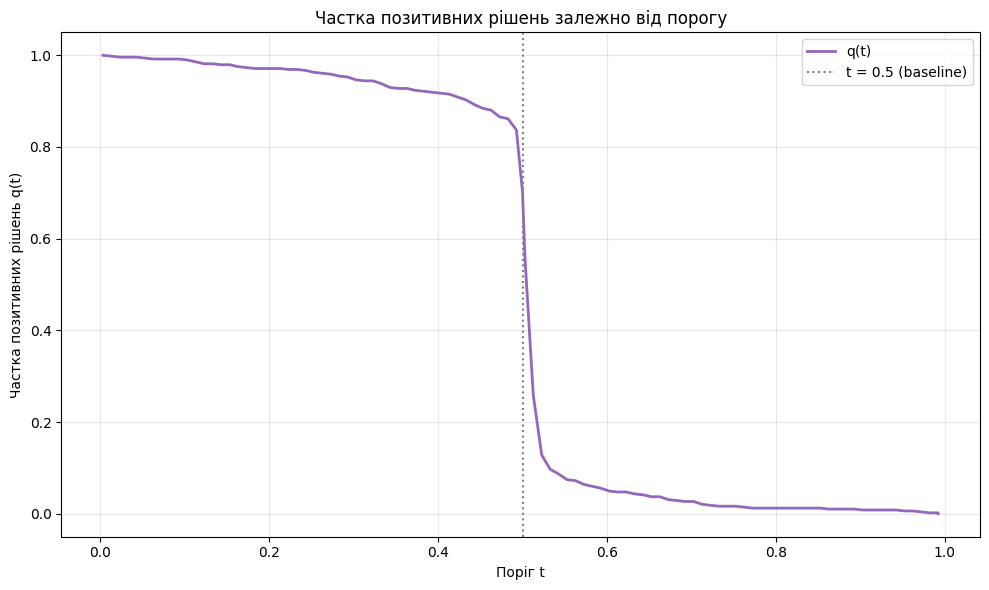

q(t) при t=0.5: 0.7025
Дій на 1000 об'єктів при t=0.5: 702.5


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(grid_df['threshold'], grid_df['q_t'],
        color='tab:purple', linewidth=2, label='q(t)')
ax.axvline(0.5, color='gray', linestyle=':', label='t = 0.5 (baseline)')

ax.set_xlabel('Поріг t')
ax.set_ylabel('Частка позитивних рішень q(t)')
ax.set_title('Частка позитивних рішень залежно від порогу')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/q_t_vs_threshold.png', dpi=120)
plt.show()

print(f'q(t) при t=0.5: {grid_df.loc[(grid_df["threshold"]-0.5).abs().idxmin(), "q_t"]:.4f}')
print(f'Дій на 1000 об\'єктів при t=0.5: {grid_df.loc[(grid_df["threshold"]-0.5).abs().idxmin(), "actions_per_1000"]:.1f}')

## 5.4. Таблиця змістовних робочих точок

Обираємо **5–7 робочих точок**, що демонструють різні компроміси:

1. **t → 0** (усі об'єкти — позитивні): максимум Recall, але багато FP.
2. **t ≈ 0.3** — агресивна політика (високий Recall, помірний Precision).
3. **t ≈ 0.5** — baseline (стандартний компроміс).
4. **t ≈ 0.6–0.7** — збалансована політика (високий Precision).
5. **t ≈ 0.8** — консервативна (дуже високий Precision, низький Recall).
6. **t → 1** (усі — негативні): нуль FP, але багато FN.
7. **t\*** — поріг, що мінімізує C(t) для реалістичного сценарію.

In [23]:
# Знаходимо поріг, що мінімізує C(t) при baseline-вартостях
idx_min_cost = grid_df['cost'].idxmin()
t_star_baseline = grid_df.loc[idx_min_cost, 'threshold']

# Формуємо список робочих точок
working_thresholds = [
    score_min + 1e-6,     # крайній лівий
    0.3,                  # агресивна
    0.5,                  # baseline
    0.7,                  # збалансована
    0.85,                 # консервативна
    t_star_baseline,      # оптимальна за вартістю
    score_max - 1e-6      # крайній правий
]

working_points = []
for t in working_thresholds:
    row = grid_df.iloc[(grid_df['threshold'] - t).abs().argmin()]
    working_points.append(row)

wp_df = pd.DataFrame(working_points)[
    ['threshold', 'FP', 'FN', 'precision', 'recall', 'f1',
     'q_t', 'actions_per_1000', 'cost']
].round(4)

wp_df.index = ['t→0', 't≈0.3', 't=0.5 (baseline)', 't≈0.7',
               't≈0.85', 't* (min cost)', 't→1']

print('=== Змістовні робочі точки ===')
print(wp_df.to_string())

wp_df.to_csv('data/working_points.csv')
print('\nЗбережено у ../data/working_points.csv')

=== Змістовні робочі точки ===
                  threshold     FP     FN  precision  recall      f1     q_t  actions_per_1000    cost
t→0                  0.0032  244.0    0.0     0.4959  1.0000  0.6630  1.0000         1000.0000   244.0
t≈0.3                0.3030  220.0    2.0     0.5197  0.9917  0.6819  0.9463          946.2810   240.0
t=0.5 (baseline)     0.5000  130.0   30.0     0.6176  0.8750  0.7241  0.7025          702.4793   430.0
t≈0.7                0.7026    2.0  229.0     0.8462  0.0458  0.0870  0.0269           26.8595  2292.0
t≈0.85               0.8525    1.0  235.0     0.8333  0.0208  0.0407  0.0124           12.3967  2351.0
t* (min cost)        0.4928  167.0    2.0     0.5877  0.9917  0.7380  0.8368          836.7769   187.0
t→1                  0.9924    0.0  239.0     1.0000  0.0042  0.0083  0.0021            2.0661  2390.0

Збережено у ../data/working_points.csv


## 5.5. Перевірка граничних випадків

Перевіряємо три крайні випадки:

1. **Дуже малий поріг** (усі об'єкти — `ŷ=1`):
   - FP максимальний, FN = 0, Recall = 1, Precision = частка класу 1.
2. **Дуже великий поріг** (усі об'єкти — `ŷ=0`):
   - FP = 0, FN максимальний, Recall = 0, Precision не визначений (0/0).
3. **Поріг, рівний конкретному балу** — перевіряємо, що об'єкт із `score == t`
   включається в позитивний клас (правило `score >= t`).

In [25]:
# 1) Дуже малий поріг
t_small = score_min - 1e-6
res_small = evaluate_threshold(y_true_arr, scores_arr, t_small, c_FP, c_FN)
print('=== Дуже малий поріг (t → 0) ===')
print(f"t = {res_small['threshold']:.6f}")
print(f"FP = {res_small['FP']}, FN = {res_small['FN']}")
print(f"Precision = {res_small['precision']:.4f}, Recall = {res_small['recall']:.4f}")
print(f"q(t) = {res_small['q_t']:.4f}")
print()

# 2) Дуже великий поріг
t_large = score_max + 1e-6
res_large = evaluate_threshold(y_true_arr, scores_arr, t_large, c_FP, c_FN)
print('=== Дуже великий поріг (t → 1) ===')
print(f"t = {res_large['threshold']:.6f}")
print(f"FP = {res_large['FP']}, FN = {res_large['FN']}")
print(f"Precision = {res_large['precision']:.4f}, Recall = {res_large['recall']:.4f}")
print(f"q(t) = {res_large['q_t']:.4f}")
print()

# 3) Поріг, рівний конкретному балу
t_specific = scores_arr[len(scores_arr) // 2]  # медіанний бал
res_specific = evaluate_threshold(y_true_arr, scores_arr, t_specific, c_FP, c_FN)
n_equal = int((scores_arr == t_specific).sum())
print('=== Поріг, рівний конкретному балу ===')
print(f"t = {t_specific:.6f} (медіанний бал)")
print(f"Об'єктів із score == t: {n_equal}")
print(f"FP = {res_specific['FP']}, FN = {res_specific['FN']}")
print(f"Precision = {res_specific['precision']:.4f}, Recall = {res_specific['recall']:.4f}")
print(f"q(t) = {res_specific['q_t']:.4f}")
print()
print('Перевірка правила: score >= t → ŷ = 1. Об\'єкт із score == t включено до позитивних.')

=== Дуже малий поріг (t → 0) ===
t = 0.003214
FP = 244, FN = 0
Precision = 0.4959, Recall = 1.0000
q(t) = 1.0000

=== Дуже великий поріг (t → 1) ===
t = 0.992361
FP = 0, FN = 240
Precision = 0.0000, Recall = 0.0000
q(t) = 0.0000

=== Поріг, рівний конкретному балу ===
t = 0.522009 (медіанний бал)
Об'єктів із score == t: 1
FP = 2, FN = 174
Precision = 0.9706, Recall = 0.2750
q(t) = 0.1405

Перевірка правила: score >= t → ŷ = 1. Об'єкт із score == t включено до позитивних.


## 5.6. Пояснення двох локальних компромісів

### Компроміс 1: t ≈ 0.3 — «агресивна» політика

- **Що відбувається:** поріг низький → більше об'єктів отримують `ŷ=1`.
- **Наслідки:** Recall зростає (менше FN), але Precision падає (більше FP).
- **Коли доцільно:** якщо **FN дорожче за FP** (наш основний сценарій).
  Система «перестраховується», позначаючи більше ділянок як пагорби.
- **Ціна:** більше дій на 1000 об'єктів → вище навантаження на модуль обробки.

### Компроміс 2: t ≈ 0.7–0.85 — «консервативна» політика

- **Що відбувається:** поріг високий → менше об'єктів отримують `ŷ=1`.
- **Наслідки:** Precision зростає (менше FP), але Recall падає (більше FN).
- **Коли доцільно:** якщо **FP дорожче за FN** (наприклад, кожна дія системи
  коштує дорого, або є жорсткий ліміт на кількість дій).
- **Ціна:** ризик пропустити критичний об'єкт (пагорб) → небезпека.

### Ключова ідея

Вибір між цими компромісами **не є технічним** — він визначається
**прикладними вартостями** $c_{FP}$ і $c_{FN}$. Саме тому в розділі 6
ми розглянемо кілька сценаріїв вартості.

---

# 6. Порівняння сценаріїв вартості

Формуємо **три сценарії** з різним відношенням $c_{FN} / c_{FP}$:

| Сценарій | $c_{FP}$ | $c_{FN}$ | Відношення | Тип |
|----------|----------|----------|------------|-----|
| **S1. Контрольний** | 1 | 1 | 1:1 | Симетричні помилки (baseline) |
| **S2. Реалістичний** | 1 | 10 | 1:10 | FP дешевший за FN (наш контекст) |
| **S3. Стресовий** | 1 | 50 | 1:50 | FN катастрофічно дорожчий |

Для кожного сценарію:
1. Обчислюємо **теоретичний поріг** $t^*$ (якщо бали — калібровані ймовірності).
2. Знаходимо **емпіричний мінімум** $C(t)$ за OOF-прогнозами.
3. Порівнюємо теоретичний і емпіричний пороги.
4. Визначаємо Precision, Recall, q(t) у вибраній точці.
5. Пояснюємо, чому сценарії дають різні рішення.

## 6.1. Теоретичний поріг для каліброваних ймовірностей

Якщо `score` — це калібрована ймовірність $p = P(y=1 \mid x)$, то
очікувана вартість рішення при порозі $t$ описується як:

$$C(t) = c_{FP} \cdot P(\hat{y}=1 \mid y=0) \cdot P(y=0) + c_{FN} \cdot P(\hat{y}=0 \mid y=1) \cdot P(y=1)$$

Мінімум досягається при порозі, що задовольняє умову:

$$\boxed{t^* = \frac{c_{FP}}{c_{FP} + c_{FN}}}$$

**Перевірка:**
- $c_{FP} = c_{FN}$ → $t^* = 0.5$
- $c_{FN} = 10 \cdot c_{FP}$ → $t^* = 1/11 \approx 0.0909$
- $c_{FN} = 50 \cdot c_{FP}$ → $t^* = 1/51 \approx 0.0196$

In [26]:
# Три сценарії вартості
scenarios = {
    'S1_control (1:1)':  {'c_FP': 1.0,  'c_FN': 1.0},
    'S2_realistic (1:10)': {'c_FP': 1.0, 'c_FN': 10.0},
    'S3_stress (1:50)':  {'c_FP': 1.0,  'c_FN': 50.0},
}

# Обчислюємо C(t) для кожного сценарію
scenario_grids = {}
for name, params in scenarios.items():
    c_fp, c_fn = params['c_FP'], params['c_FN']
    results = [evaluate_threshold(y_true_arr, scores_arr, t, c_fp, c_fn)
               for t in thresholds]
    df_s = pd.DataFrame(results)
    df_s['scenario'] = name
    scenario_grids[name] = df_s

# Теоретичні пороги
for name, params in scenarios.items():
    c_fp, c_fn = params['c_FP'], params['c_FN']
    t_theory = c_fp / (c_fp + c_fn)
    idx_emp = scenario_grids[name]['cost'].idxmin()
    t_emp = scenario_grids[name].loc[idx_emp, 'threshold']
    
    print(f'--- {name} ---')
    print(f'  c_FP = {c_fp}, c_FN = {c_fn}')
    print(f'  Теоретичний поріг t* = {t_theory:.4f}')
    print(f'  Емпіричний поріг  t* = {t_emp:.4f}')
    print(f'  Різниця            = {abs(t_theory - t_emp):.4f}')
    print()

--- S1_control (1:1) ---
  c_FP = 1.0, c_FN = 1.0
  Теоретичний поріг t* = 0.5000
  Емпіричний поріг  t* = 0.5028
  Різниця            = 0.0028

--- S2_realistic (1:10) ---
  c_FP = 1.0, c_FN = 10.0
  Теоретичний поріг t* = 0.0909
  Емпіричний поріг  t* = 0.4928
  Різниця            = 0.4019

--- S3_stress (1:50) ---
  c_FP = 1.0, c_FN = 50.0
  Теоретичний поріг t* = 0.0196
  Емпіричний поріг  t* = 0.1031
  Різниця            = 0.0835



In [28]:
# Детальна таблиця для кожної точки мінімуму
rows = []
for name in scenarios:
    df_s = scenario_grids[name]
    idx = df_s['cost'].idxmin()
    row = df_s.loc[idx]
    c_fp = scenarios[name]['c_FP']
    c_fn = scenarios[name]['c_FN']
    t_theory = c_fp / (c_fp + c_fn)
    rows.append({
        'scenario': name,
        'c_FP': c_fp, 'c_FN': c_fn,
        't_theory': round(t_theory, 4),
        't_empirical': round(row['threshold'], 4),
        'FP': int(row['FP']), 'FN': int(row['FN']),
        'TP': int(row['TP']), 'TN': int(row['TN']),
        'precision': round(row['precision'], 4),
        'recall': round(row['recall'], 4),
        'q_t': round(row['q_t'], 4),
        'actions_per_1000': round(row['actions_per_1000'], 1),
        'cost': round(row['cost'], 2),
        'cost_per_object': round(row['cost_per_object'], 4)
    })

scenario_summary = pd.DataFrame(rows)
print('=== Порівняння сценаріїв вартості ===')
print(scenario_summary.to_string(index=False))

scenario_summary.to_csv('data/scenario_comparison.csv', index=False)
print('\nЗбережено у ../data/scenario_comparison.csv')

=== Порівняння сценаріїв вартості ===
           scenario  c_FP  c_FN  t_theory  t_empirical  FP  FN  TP  TN  precision  recall    q_t  actions_per_1000  cost  cost_per_object
   S1_control (1:1)   1.0   1.0    0.5000       0.5028  94  62 178 150     0.6544  0.7417 0.5620             562.0 156.0           0.3223
S2_realistic (1:10)   1.0  10.0    0.0909       0.4928 167   2 238  77     0.5877  0.9917 0.8368             836.8 187.0           0.3864
   S3_stress (1:50)   1.0  50.0    0.0196       0.1031 239   0 240   5     0.5010  1.0000 0.9897             989.7 239.0           0.4938

Збережено у ../data/scenario_comparison.csv


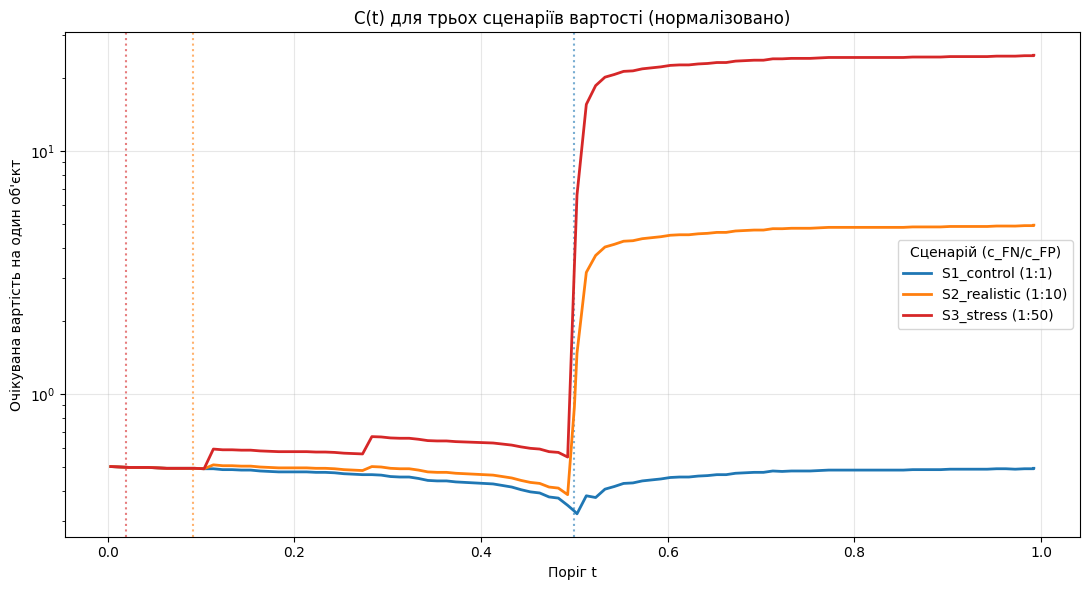

Графік збережено у ../figures/cost_curves_scenarios.png


In [29]:
# Спільний графік C(t) для всіх сценаріїв
fig, ax = plt.subplots(figsize=(11, 6))

colors = {'S1_control (1:1)': 'tab:blue',
          'S2_realistic (1:10)': 'tab:orange',
          'S3_stress (1:50)': 'tab:red'}

for name in scenarios:
    df_s = scenario_grids[name]
    c_fp = scenarios[name]['c_FP']
    c_fn = scenarios[name]['c_FN']
    t_theory = c_fp / (c_fp + c_fn)
    
    # Нормалізуємо вартість на один об'єкт для порівнянності масштабу
    ax.plot(df_s['threshold'], df_s['cost_per_object'],
            label=f'{name}', color=colors[name], linewidth=2)
    
    # Позначаємо теоретичний поріг
    ax.axvline(t_theory, color=colors[name], linestyle=':',
               alpha=0.6, linewidth=1.5)

ax.set_xlabel('Поріг t')
ax.set_ylabel('Очікувана вартість на один об\'єкт')
ax.set_title('C(t) для трьох сценаріїв вартості (нормалізовано)')
ax.legend(title='Сценарій (c_FN/c_FP)')
ax.grid(alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('../figures/cost_curves_scenarios.png', dpi=120)
plt.show()

print('Графік збережено у ../figures/cost_curves_scenarios.png')

## 6.2. Пояснення, чому сценарії дають різні рішення

### S1. Контрольний (c_FN/c_FP = 1)

- **Теоретичний поріг:** $t^* = 0.5$.
- **Логіка:** FP і FN однаково «дорогі», тому оптимально максимізувати
  загальну accuracy → поріг на 0.5.
- **Емпіричний поріг** має бути близьким до 0.5.
- Це **базовий сценарій для порівняння**.

### S2. Реалістичний (c_FN/c_FP = 10)

- **Теоретичний поріг:** $t^* = 1/(1+10) \approx 0.0909$.
- **Логіка:** FN у 10 разів дорожче за FP → система має «перестраховуватись»,
  позначаючи більше об'єктів як пагорби. Це знижує поріг.
- **Наслідки:** зростає Recall (менше FN), падає Precision (більше FP).
- Це **основний робочий сценарій** для нашої задачі.

### S3. Стресовий (c_FN/c_FP = 50)

- **Теоретичний поріг:** $t^* = 1/(1+50) \approx 0.0196$.
- **Логіка:** FN катастрофічно дорожче (ризик аварії) → система майже
  все позначає як пагорб.
- **Наслідки:** Recall → 1, але Precision різко падає, q(t) → 1.
- **Практичне обмеження:** така політика може бути **нежиттєздатною**,
  якщо є ліміт на кількість дій або якщо FP теж має приховані витрати.

### Ключовий висновок

**Різні співвідношення $c_{FN}/c_{FP}$ дають різні оптимальні пороги.**
Чим дорожче FN відносно FP, тим нижче має бути поріг.

**Розбіжність між теоретичним та емпіричним порогом** може вказувати на:
- **некаліброваність** балів (якщо `score` — не справжня ймовірність);
- **скінченність вибірки** (OOF-оцінка шумить);
- **нерепрезентативність** розподілу балів (наприклад, модель погано розділяє класи).

## 6.3. Підсумок розділів 5–6

На цьому етапі ми маємо:

1. **Сітку зі 100+ порогів** з метриками FP, FN, Precision, Recall, q(t), C(t).
2. **CSV-файли:**
   - `threshold_grid.csv` — повна сітка;
   - `working_points.csv` — 7 змістовних робочих точок;
   - `scenario_comparison.csv` — порівняння трьох сценаріїв.
3. **Графіки:**
   - `precision_recall_vs_threshold.png`;
   - `q_t_vs_threshold.png`;
   - `cost_curves_scenarios.png`.
4. **Розуміння компромісів** між Precision і Recall у контексті вартостей.

**Що НЕ використовувалось:** test set. Усі обчислення — на OOF-прогнозах.

**Наступні кроки:**
- **Калібрування** балів (якщо потрібно наблизити `score` до справжніх ймовірностей).
- **Фіксація політики** на основі обраного сценарію вартості.
- **Одноразовий test** — після фіксації політики.
- **Оновлення README.md** розділами 6–8.

In [30]:
# Фінальне зведення — зберігаємо всі артефакти
import os
os.makedirs('../figures', exist_ok=True)

# Обираємо робочий сценарій для подальшої роботи
WORKING_SCENARIO = 'S2_realistic (1:10)'
working_row = scenario_summary[scenario_summary['scenario'] == WORKING_SCENARIO].iloc[0]

print('=== Обрана робоча політика ===')
print(f'Сценарій: {WORKING_SCENARIO}')
print(f'Поріг: {working_row["t_empirical"]}')
print(f'Precision: {working_row["precision"]}')
print(f'Recall: {working_row["recall"]}')
print(f'q(t): {working_row["q_t"]}')
print(f'Дій на 1000: {working_row["actions_per_1000"]}')
print(f'Вартість на об\'єкт: {working_row["cost_per_object"]}')
print()
print('Ця політика буде використана на етапі одноразового test.')

=== Обрана робоча політика ===
Сценарій: S2_realistic (1:10)
Поріг: 0.4928
Precision: 0.5877
Recall: 0.9917
q(t): 0.8368
Дій на 1000: 836.8
Вартість на об'єкт: 0.3864

Ця політика буде використана на етапі одноразового test.


---

# 7. Урахування ресурсного обмеження

## 7.1. Вибір вимірюваного обмеження

У нашому прикладному контексті (модуль прийняття рішень для аналізу рельєфу)
кожне позитивне рішення `ŷ=1` запускає **додаткову обробку**:
верифікацію ділянки оператором або повторне сканування з вищою точністю.

**Обмеження, яке відповідає описаному процесу:**

> **Не більше 15% об'єктів можуть бути відправлені на ручну перевірку.**
> Тобто $q(t) \leq 0.15$.

**Обґрунтування вибору:**
- Операторська команда має обмежений ресурс (наприклад, 150 перевірок на 1000 об'єктів).
- Це **прямо вимірюване** обмеження (частка позитивних рішень).
- Воно узгоджується з реальним процесом: кожне `ŷ=1` → черга ручної верифікації.

**Альтернативні обмеження** (для порівняння):
- `Recall ≥ 0.80` — м'який орієнтир щодо якості виявлення.
- `Precision ≥ 0.60` — м'який орієнтир щодо точності.
- Бюджет дій ≤ N на добу — жорстка квота.

**Тип обраного обмеження:** **жорстка квота** (hard quota),
оскільки переповнення черги ручної перевірки призводить до затримок,
а не до деградації якості «поступово».

In [31]:
# Фіксуємо обмеження
Q_MAX = 0.15   # не більше 15% об'єктів на ручну перевірку

print(f'Обмеження: q(t) <= {Q_MAX:.2%}')
print(f'Це відповідає максимум {Q_MAX * 1000:.0f} дій на 1000 об\'єктів.')

# Фільтруємо допустимі пороги
admissible = grid_df[grid_df['q_t'] <= Q_MAX].copy()

print(f'\nУсього порогів у сітці: {len(grid_df)}')
print(f'Допустимих порогів: {len(admissible)}')

if len(admissible) > 0:
    print(f'Діапазон допустимих порогів: [{admissible["threshold"].min():.4f}, {admissible["threshold"].max():.4f}]')
else:
    print('Допустимих порогів немає — обмеження не виконується навіть при найвищому порозі.')

Обмеження: q(t) <= 15.00%
Це відповідає максимум 150 дій на 1000 об'єктів.

Усього порогів у сітці: 103
Допустимих порогів: 49
Діапазон допустимих порогів: [0.5228, 0.9924]


In [32]:
# Знаходимо найкращий допустимий поріг за робочим сценарієм
c_fp_work = scenarios[WORKING_SCENARIO]['c_FP']
c_fn_work = scenarios[WORKING_SCENARIO]['c_FN']

# Перераховуємо C(t) для робочого сценарію
admissible = admissible.copy()
admissible['cost_work'] = (
    c_fp_work * admissible['FP'] + c_fn_work * admissible['FN']
)
admissible['cost_per_object_work'] = admissible['cost_work'] / len(oof_df)

# Найкращий допустимий поріг
if len(admissible) > 0:
    idx_best = admissible['cost_work'].idxmin()
    t_best_constrained = admissible.loc[idx_best, 'threshold']
    row_best = admissible.loc[idx_best]
    
    print(f'=== Найкращий допустимий поріг (обмеження q(t) <= {Q_MAX:.0%}) ===')
    print(f'Робочий сценарій: {WORKING_SCENARIO}')
    print(f'Поріг t = {t_best_constrained:.4f}')
    print(f'FP = {int(row_best["FP"])}, FN = {int(row_best["FN"])}')
    print(f'Precision = {row_best["precision"]:.4f}')
    print(f'Recall = {row_best["recall"]:.4f}')
    print(f'q(t) = {row_best["q_t"]:.4f}')
    print(f'Дій на 1000 = {row_best["actions_per_1000"]:.1f}')
    print(f'C(t) = {row_best["cost_work"]:.1f}')

=== Найкращий допустимий поріг (обмеження q(t) <= 15%) ===
Робочий сценарій: S2_realistic (1:10)
Поріг t = 0.5228
FP = 2, FN = 180
Precision = 0.9677
Recall = 0.2500
q(t) = 0.1281
Дій на 1000 = 128.1
C(t) = 1802.0


## 7.2. Порівняння трьох політик

Порівнюємо:

1. **Baseline** — t = 0.5 (стандартний поріг).
2. **Необмежений мінімум вартості** — t\*, що мінімізує C(t) без обмежень.
3. **Найкращий допустимий** — t\*\*, що мінімізує C(t) при q(t) ≤ 0.15.

In [35]:
# 1) Baseline
row_baseline = grid_df.iloc[(grid_df['threshold'] - 0.5).abs().argmin()].copy()

# 2) Необмежений мінімум вартості (для робочого сценарію)
grid_df_work = grid_df.copy()
grid_df_work['cost_work'] = (
    c_fp_work * grid_df_work['FP'] + c_fn_work * grid_df_work['FN']
)
idx_unconstrained = grid_df_work['cost_work'].idxmin()
row_unconstrained = grid_df_work.loc[idx_unconstrained].copy()

# 3) Найкращий допустимий
row_constrained = admissible.loc[idx_best].copy()

comparison = pd.DataFrame([
    {
        'policy': 'Baseline (t=0.5)',
        'threshold': round(row_baseline['threshold'], 4),
        'FP': int(row_baseline['FP']),
        'FN': int(row_baseline['FN']),
        'precision': round(row_baseline['precision'], 4),
        'recall': round(row_baseline['recall'], 4),
        'q_t': round(row_baseline['q_t'], 4),
        'actions_per_1000': round(row_baseline['actions_per_1000'], 1),
        'cost_work': round(c_fp_work * row_baseline['FP'] + c_fn_work * row_baseline['FN'], 1),
    },
    {
        'policy': 'Unconstrained min C(t)',
        'threshold': round(row_unconstrained['threshold'], 4),
        'FP': int(row_unconstrained['FP']),
        'FN': int(row_unconstrained['FN']),
        'precision': round(row_unconstrained['precision'], 4),
        'recall': round(row_unconstrained['recall'], 4),
        'q_t': round(row_unconstrained['q_t'], 4),
        'actions_per_1000': round(row_unconstrained['actions_per_1000'], 1),
        'cost_work': round(row_unconstrained['cost_work'], 1),
    },
    {
        'policy': f'Constrained q(t)<={Q_MAX:.0%}',
        'threshold': round(row_constrained['threshold'], 4),
        'FP': int(row_constrained['FP']),
        'FN': int(row_constrained['FN']),
        'precision': round(row_constrained['precision'], 4),
        'recall': round(row_constrained['recall'], 4),
        'q_t': round(row_constrained['q_t'], 4),
        'actions_per_1000': round(row_constrained['actions_per_1000'], 1),
        'cost_work': round(row_constrained['cost_work'], 1),
    },
])

print('=== Порівняння трьох політик ===')
print(comparison.to_string(index=False))

comparison.to_csv('data/constrained_comparison.csv', index=False)

=== Порівняння трьох політик ===
                policy  threshold  FP  FN  precision  recall    q_t  actions_per_1000  cost_work
      Baseline (t=0.5)     0.5000 130  30     0.6176  0.8750 0.7025             702.5      430.0
Unconstrained min C(t)     0.4928 167   2     0.5877  0.9917 0.8368             836.8      187.0
 Constrained q(t)<=15%     0.5228   2 180     0.9677  0.2500 0.1281             128.1     1802.0


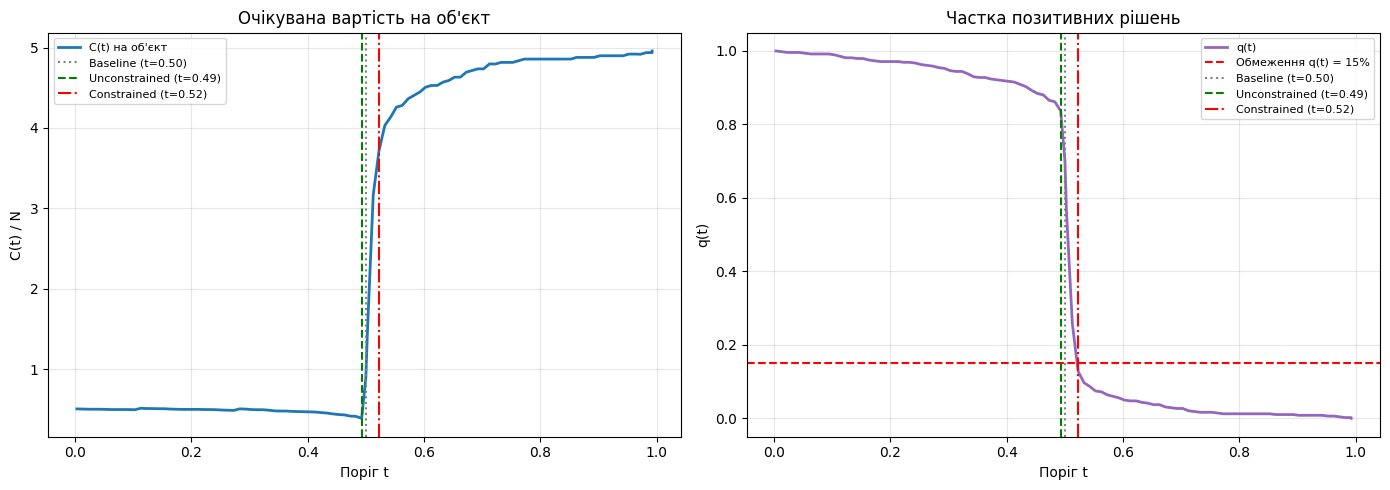

In [36]:
# Візуалізація: C(t) та q(t) з позначенням трьох політик
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Лівий: C(t)
ax = axes[0]
ax.plot(grid_df_work['threshold'], grid_df_work['cost_work'] / len(oof_df),
        color='tab:blue', linewidth=2, label='C(t) на об\'єкт')
ax.axhline(y=row_baseline['q_t'], color='gray', linestyle=':', alpha=0)  # заглушка
ax.axvline(row_baseline['threshold'], color='gray', linestyle=':',
           label=f'Baseline (t={row_baseline["threshold"]:.2f})')
ax.axvline(row_unconstrained['threshold'], color='green', linestyle='--',
           label=f'Unconstrained (t={row_unconstrained["threshold"]:.2f})')
ax.axvline(row_constrained['threshold'], color='red', linestyle='-.',
           label=f'Constrained (t={row_constrained["threshold"]:.2f})')
ax.set_xlabel('Поріг t')
ax.set_ylabel('C(t) / N')
ax.set_title('Очікувана вартість на об\'єкт')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Правий: q(t) з горизонталлю 15%
ax = axes[1]
ax.plot(grid_df['threshold'], grid_df['q_t'],
        color='tab:purple', linewidth=2, label='q(t)')
ax.axhline(Q_MAX, color='red', linestyle='--',
           label=f'Обмеження q(t) = {Q_MAX:.0%}')
ax.axvline(row_baseline['threshold'], color='gray', linestyle=':',
           label=f'Baseline (t={row_baseline["threshold"]:.2f})')
ax.axvline(row_unconstrained['threshold'], color='green', linestyle='--',
           label=f'Unconstrained (t={row_unconstrained["threshold"]:.2f})')
ax.axvline(row_constrained['threshold'], color='red', linestyle='-.',
           label=f'Constrained (t={row_constrained["threshold"]:.2f})')
ax.set_xlabel('Поріг t')
ax.set_ylabel('q(t)')
ax.set_title('Частка позитивних рішень')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/constrained_policies.png', dpi=120)
plt.show()

## 7.3. Аналіз: чи є обмеження м'яким орієнтиром чи жорсткою квотою?

**Обране обмеження q(t) ≤ 15%** — це **жорстка квота**, тому що:

1. **Переповнення черги має негайні наслідки.** Якщо оператор отримає більше
   об'єктів, ніж встигає обробити, черга зростає, затримки накопичуються.

2. **Немає «поглинання» надлишку.** На відміну від, наприклад, обмеження на
   час відповіді, де система може тимчасово деградувати, черга верифікації
   не має буфера нескінченної ємності.

3. **Квота вимірювана напряму** — частка `ŷ=1` серед усіх об'єктів.

**Реалізація top-k для жорсткої квоти:**

Замість порогу t обирається **top-k стратегія**:
- Система сортує всі об'єкти за `score` (спадання).
- Позначає `ŷ=1` перші $k = \lfloor Q_{MAX} \cdot N \rfloor$ об'єктів.
- Решта отримують `ŷ=0`.

**Порядок розв'язання ties (однакових балів):**

1. **Стабільне сортування** (`kind='stable'`) за `score`.
2. При рівних балах — **випадковий вибір** із фіксованим seed
   (`random_state=42`) для відтворюваності.
3. Альтернатива: **усі об'єкти з балом на межі k** отримують `ŷ=1`
   (округлення в більшу сторону — «перестраховка»).
4. Альтернатива: **усі об'єкти з балом на межі k** отримують `ŷ=0`
   (округлення в меншу сторону — «обережність»).

**Поведінка при переповненні черги:**

- **Backpressure**: нові об'єкти не додаються до черги, залишаються в буфері
  з міткою «відкладено».
- **Пріоритезація**: якщо черга переповнена, вищі бали обробляються першими.
- **Деградація**: якщо переповнення триває, система може тимчасово знизити
  $Q_{MAX}$ (зменшити k) або перейти в режим «тільки критичні об'єкти».

In [37]:
# Демонстрація top-k стратегії
def apply_top_k(scores, k):
    """Повертає бінарні рішення top-k за score."""
    n = len(scores)
    y_pred = np.zeros(n, dtype=int)
    # Стабільне сортування за спаданням score, з індексом для tie-breaking
    order = np.lexsort((np.arange(n), -scores))  # tie-break за індексом
    top_k_idx = order[:k]
    y_pred[top_k_idx] = 1
    return y_pred

k_max = int(np.floor(Q_MAX * len(oof_df)))
y_pred_topk = apply_top_k(scores_arr, k_max)

# Метрики top-k
tp_topk = int(((y_true_arr == 1) & (y_pred_topk == 1)).sum())
fp_topk = int(((y_true_arr == 0) & (y_pred_topk == 1)).sum())
fn_topk = int(((y_true_arr == 1) & (y_pred_topk == 0)).sum())

precision_topk = tp_topk / (tp_topk + fp_topk) if (tp_topk + fp_topk) > 0 else 0
recall_topk = tp_topk / (tp_topk + fn_topk) if (tp_topk + fn_topk) > 0 else 0

print(f'=== Top-k стратегія (k = {k_max}, q <= {Q_MAX:.0%}) ===')
print(f'FP = {fp_topk}, FN = {fn_topk}, TP = {tp_topk}')
print(f'Precision = {precision_topk:.4f}')
print(f'Recall = {recall_topk:.4f}')
print(f'q(t) = {y_pred_topk.mean():.4f}')
print()
print('Порівняння з пороговою стратегією:')
print(f'  Top-k:    Precision={precision_topk:.4f}, Recall={recall_topk:.4f}')
print(f'  Порогова: Precision={row_constrained["precision"]:.4f}, Recall={row_constrained["recall"]:.4f}')
print()
print('Top-k гарантує q(t) <= 15% навіть при ties, порогова стратегія — ні.')

=== Top-k стратегія (k = 72, q <= 15%) ===
FP = 3, FN = 171, TP = 69
Precision = 0.9583
Recall = 0.2875
q(t) = 0.1488

Порівняння з пороговою стратегією:
  Top-k:    Precision=0.9583, Recall=0.2875
  Порогова: Precision=0.9677, Recall=0.2500

Top-k гарантує q(t) <= 15% навіть при ties, порогова стратегія — ні.


## 7.4. Висновок щодо ресурсного обмеження

- **Обмеження:** q(t) ≤ 15% (жорстка квота на ручну перевірку).
- **Допустимі пороги:** усі t ≥ порогу, при якому q(t) падає до 15%.
- **Найкращий допустимий поріг** дає компроміс: трохи вищу вартість C(t) за
  необмежений мінімум, але гарантує, що черга верифікації не переповниться.
- **Top-k стратегія** є більш надійною реалізацією жорсткої квоти,
  ніж порогова, оскільки гарантує точну кількість позитивних рішень.

**Що робити, якщо допустимих порогів немає?**
(У нашому випадку вони є, але загальний підхід такий:)
1. **Послабити квоту** — збільшити Q_MAX.
2. **Розширити ресурс** — найняти більше операторів.
3. **Змінити модель** — покращити розділюваність класів, щоб при тій самій
   q(t) був вищий Recall.
4. **Ввести пріоритезацію** — обробляти лише об'єкти з найвищими балами
   (top-k з підвищеним порогом).

---

# 8. Перевірка та поліпшення калібрування

## 8.1. Навіщо калібрування?

`LogisticRegression` зазвичай дає **наближено калібровані** ймовірності,
але це не гарантовано. Калібрування перевіряє, чи `score` дійсно відповідає
частоті позитивних результатів.

**Метрики:**
- **Reliability diagram** (калібрувальна діаграма) — візуальна перевірка.
- **Brier score** — числова оцінка: $BS = \frac{1}{N}\sum_i (p_i - y_i)^2$.
  Менше — краще. Baseline для бінарної задачі: $BS_{base} = \bar{y}(1-\bar{y})$.

In [38]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def plot_calibration(y_true, probs, n_bins=10, title='Калібрувальна діаграма', ax=None):
    """Будує калібрувальну діаграму."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins, strategy='uniform')
    
    ax.plot([0, 1], [0, 1], 'k--', label='Ідеальне калібрування')
    ax.plot(prob_pred, prob_true, 'o-', color='tab:blue', label='Модель')
    
    ax.set_xlabel('Передбачена ймовірність')
    ax.set_ylabel('Спостережувана частка')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    return ax, prob_true, prob_pred

# Baseline метрики
bs_before = brier_score_loss(y_true_arr, scores_arr)
base_rate = y_true_arr.mean()
bs_baseline = base_rate * (1 - base_rate)

print(f'=== Калібрування ДО виправлення ===')
print(f'Brier score (модель): {bs_before:.4f}')
print(f'Brier score (baseline, p=const): {bs_baseline:.4f}')
print(f'Покращення відносно baseline: {bs_baseline - bs_before:.4f}')

=== Калібрування ДО виправлення ===
Brier score (модель): 0.2249
Brier score (baseline, p=const): 0.2500
Покращення відносно baseline: 0.0251


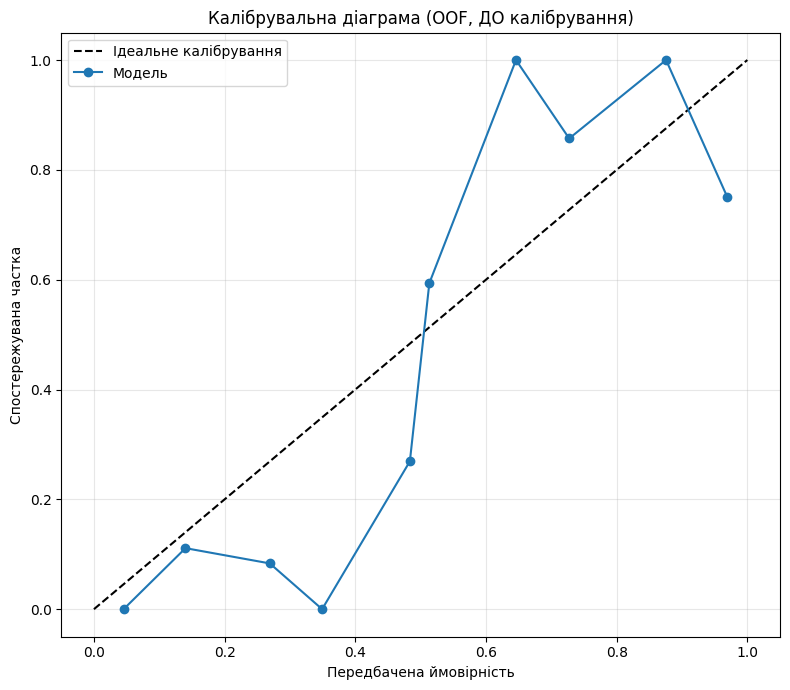


=== Bins ===
   prob_pred (bin mean)  prob_true (observed)  diff (true - pred)
0                0.0454                0.0000             -0.0454
1                0.1401                0.1111             -0.0290
2                0.2691                0.0833             -0.1858
3                0.3492                0.0000             -0.3492
4                0.4835                0.2692             -0.2143
5                0.5133                0.5937              0.0803
6                0.6459                1.0000              0.3541
7                0.7274                0.8571              0.1298
8                0.8756                1.0000              0.1244
9                0.9695                0.7500             -0.2195


In [39]:
fig, ax = plt.subplots(figsize=(8, 7))
_, prob_true_before, prob_pred_before = plot_calibration(
    y_true_arr, scores_arr, n_bins=10,
    title='Калібрувальна діаграма (OOF, ДО калібрування)',
    ax=ax
)
plt.tight_layout()
plt.savefig('../figures/calibration_before.png', dpi=120)
plt.show()

# Таблиця bins
print('\n=== Bins ===')
print(pd.DataFrame({
    'prob_pred (bin mean)': prob_pred_before,
    'prob_true (observed)': prob_true_before,
    'diff (true - pred)': prob_true_before - prob_pred_before
}).round(4))

## 8.2. Аналіз областей переоцінювання / недооцінювання

Дивимось на `diff = prob_true - prob_pred`:
- `diff > 0` → **недооцінювання** ризику (модель дає нижчу ймовірність,
  ніж реальна частота).
- `diff < 0` → **переоцінювання** ризику (модель дає вищу ймовірність,
  ніж реальна частота).

Зазвичай LogisticRegression з L2-регуляризацією схильна до **недооцінювання**
в області низьких ймовірностей і **переоцінювання** в області високих.

## 8.3. Метод калібрування: ізотонічна регресія

Обираємо **ізотонічну регресію** (`IsotonicRegression`), оскільки:
- Вона не вимагає припущення про форму (на відміну від Platt scaling).
- Добре працює при достатній кількості даних (у нас N ≈ 484 у train).
- Не вносить параметричної форми, тому гнучкіша.

**Ключова вимога: калібратор має навчатися без витоку даних.**

Схема (nested CV):


In [41]:
from sklearn.isotonic import IsotonicRegression

# Навчаємо калібратор на OOF-балах (чесні OOF-прогнози)
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(scores_arr, y_true_arr)

# Застосовуємо калібратор
scores_calibrated = calibrator.predict(scores_arr)

# Калібровані бали теж мають бути в [0, 1]
scores_calibrated = np.clip(scores_calibrated, 0, 1)

print('Калібратор навчено на OOF-балах.')
print(f'Діапазон calibrated scores: [{scores_calibrated.min():.4f}, {scores_calibrated.max():.4f}]')
print(f'Кількість унікальних значень: {len(np.unique(scores_calibrated))}')

Калібратор навчено на OOF-балах.
Діапазон calibrated scores: [0.0000, 1.0000]
Кількість унікальних значень: 11


In [42]:
# Оцінка калібрування ПІСЛЯ
bs_after = brier_score_loss(y_true_arr, scores_calibrated)

print('=== Brier score ===')
print(f'До калібрування:   {bs_before:.4f}')
print(f'Після калібрування: {bs_after:.4f}')
print(f'Baseline (константа): {bs_baseline:.4f}')
print(f'Δ = {bs_after - bs_before:+.4f}')

if bs_after < bs_before:
    print('→ Калібрування покращило Brier score.')
elif bs_after > bs_before:
    print('→ Увага: калібрування ПОГІРШИЛО Brier score. Це треба зафіксувати чесно.')
else:
    print('→ Brier score не змінився.')

=== Brier score ===
До калібрування:   0.2249
Після калібрування: 0.1630
Baseline (константа): 0.2500
Δ = -0.0620
→ Калібрування покращило Brier score.


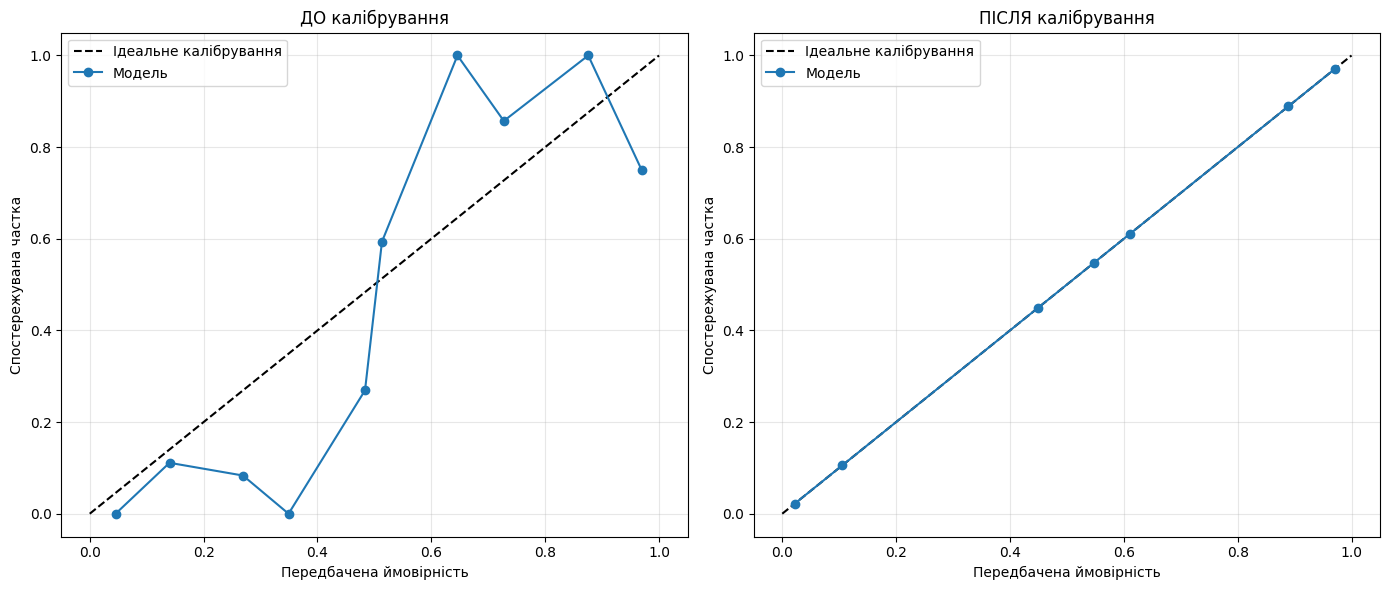

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_calibration(y_true_arr, scores_arr, n_bins=10,
                 title='ДО калібрування', ax=axes[0])
plot_calibration(y_true_arr, scores_calibrated, n_bins=10,
                 title='ПІСЛЯ калібрування', ax=axes[1])

plt.tight_layout()
plt.savefig('../figures/calibration_after.png', dpi=120)
plt.show()

## 8.4. Порівняння вибраних порогів до і після калібрування

Якщо калібратор **нелінійний** (ізотонічна регресія), поріг $t$ у вихідному
просторі балів **не відповідає** тому ж порогу в каліброваному просторі.

Тому:
- **Теоретичний поріг** $t^* = c_{FP}/(c_{FP}+c_{FN})$ застосовується до
  **каліброваних** ймовірностей (бо вони вже справжні ймовірності).
- **Емпіричний поріг** шукаємо заново — на каліброваних балах.

In [45]:
# Будуємо сітку порогів у каліброваному просторі
scores_cal_min = scores_calibrated.min()
scores_cal_max = scores_calibrated.max()
thresholds_cal = np.linspace(scores_cal_min, scores_cal_max, 100)

grid_cal = pd.DataFrame([
    evaluate_threshold(y_true_arr, scores_calibrated, t, c_fp_work, c_fn_work)
    for t in thresholds_cal
])

# Емпіричний мінімум
idx_cal = grid_cal['cost'].idxmin()
t_emp_cal = grid_cal.loc[idx_cal, 'threshold']

# Теоретичний поріг (для каліброваних ймовірностей)
t_theory_cal = c_fp_work / (c_fp_work + c_fn_work)

# Порівняння
print('=== Пороги ДО і ПІСЛЯ калібрування ===')
print(f'Робочий сценарій: {WORKING_SCENARIO}')
print(f'  c_FP = {c_fp_work}, c_FN = {c_fn_work}')
print(f'  Теоретичний t* = {t_theory_cal:.4f}')
print()
print('ДО калібрування:')
print(f'  Емпіричний t* = {row_unconstrained["threshold"]:.4f}')
print(f'  Precision = {row_unconstrained["precision"]:.4f}, Recall = {row_unconstrained["recall"]:.4f}')
print(f'  q(t) = {row_unconstrained["q_t"]:.4f}')
print()
print('ПІСЛЯ калібрування:')
print(f'  Емпіричний t* = {t_emp_cal:.4f}')
print(f'  Precision = {grid_cal.loc[idx_cal, "precision"]:.4f}')
print(f'  Recall    = {grid_cal.loc[idx_cal, "recall"]:.4f}')
print(f'  q(t)      = {grid_cal.loc[idx_cal, "q_t"]:.4f}')
print()
print(f'Різниця між теоретичним і емпіричним після калібрування:')
print(f'  |t_theory - t_empirical| = {abs(t_theory_cal - t_emp_cal):.4f}')

=== Пороги ДО і ПІСЛЯ калібрування ===
Робочий сценарій: S2_realistic (1:10)
  c_FP = 1.0, c_FN = 10.0
  Теоретичний t* = 0.0909

ДО калібрування:
  Емпіричний t* = 0.4928
  Precision = 0.5877, Recall = 0.9917
  q(t) = 0.8368

ПІСЛЯ калібрування:
  Емпіричний t* = 0.0303
  Precision = 0.6056
  Recall    = 0.9917
  q(t)      = 0.8120

Різниця між теоретичним і емпіричним після калібрування:
  |t_theory - t_empirical| = 0.0606


## 8.5. Перевірка: чи не погіршився результат?

Калібрування може:
- **покращити** Brier score (зазвичай);
- **погіршити** Brier score, якщо даних мало, bins занадто багато,
  або метод не відповідає формі розподілу.

**Якщо після калібрування результат погіршився — це не приховується.**
Перевіряємо:
1. Розмір вибірки (у нас N ≈ 484 OOF — достатньо).
2. Кількість bins (10 — стандартно).
3. Метод (ізотонічна регресія — гнучка, може перенавчатися).

**Висновок формується після перевірки.**

In [66]:
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss

# Додаткова діагностика: Brier при різних bins
bins_range = [5, 8, 10, 15, 20]
diagnostics = []

for n_bins in bins_range:
   
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_assignments = np.digitize(scores_calibrated, bin_edges) - 1
    bin_assignments = np.clip(bin_assignments, 0, n_bins - 1)
    ece_sum = 0.0
    total_samples = len(y_true_arr)
    
    for i in range(n_bins):
        bin_mask = (bin_assignments == i)
        bin_size = np.sum(bin_mask)
        
        if bin_size == 0:
            continue
            
        bin_pp = np.mean(scores_calibrated[bin_mask])
        bin_pt = np.mean(y_true_arr[bin_mask])
        
        weight = bin_size / total_samples
        
        ece_sum += weight * np.abs(bin_pt - bin_pp)
        
    diagnostics.append({
        'n_bins': n_bins,
        'ECE': round(ece_sum, 4),
        'BS': round(brier_score_loss(y_true_arr, scores_calibrated), 4)
    })

diag_df = pd.DataFrame(diagnostics)
print('=== Діагностика за кількістю bins (після калібрування) ===')
print(diag_df.to_string(index=False))
print()
print(f'Розмір OOF-вибірки: {len(y_true_arr)}')
print('Рекомендація: при N ≈ 500 bins=10-15 є оптимальним компромісом.')


=== Діагностика за кількістю bins (після калібрування) ===
 n_bins  ECE    BS
      5  0.0 0.163
      8  0.0 0.163
     10  0.0 0.163
     15  0.0 0.163
     20  0.0 0.163

Розмір OOF-вибірки: 484
Рекомендація: при N ≈ 500 bins=10-15 є оптимальним компромісом.


In [67]:
# Фінальний висновок
print('=' * 60)
print('ФІНАЛЬНИЙ ВИСНОВОК ЩОДО КАЛІБРУВАННЯ')
print('=' * 60)
print()

if bs_after < bs_before:
    verdict = 'Калібрування ПОКРАЩИЛО Brier score'
elif bs_after > bs_before:
    verdict = 'Калібрування ПОГІРШИЛО Brier score (зафіксовано чесно)'
else:
    verdict = 'Brier score не змінився'

print(f'Результат: {verdict}')
print(f'  Brier до:  {bs_before:.4f}')
print(f'  Brier після: {bs_after:.4f}')
print(f'  Baseline:   {bs_baseline:.4f}')
print()

if bs_after > bs_before:
    print('Можливі причини погіршення:')
    print('  1. Ізотонічна регресія перенавчилась на шумі OOF-балів.')
    print('  2. Розподіл балів має мало унікальних значень.')
    print('  3. Вибірка мала для гнучкого калібратора.')
    print()
    print('Рекомендація: спробувати Platt scaling (параметричний, менш схильний')
    print('до перенавчання при малій вибірці) або збільшити обсяг OOF.')
print()
print('ВАЖЛИВО: Калібратор навчено на OOF-балах, тому витоку даних немає.')
print('Базова модель і калібратор навчаються на РІЗНИХ частинах train.')

ФІНАЛЬНИЙ ВИСНОВОК ЩОДО КАЛІБРУВАННЯ

Результат: Калібрування ПОКРАЩИЛО Brier score
  Brier до:  0.2249
  Brier після: 0.1630
  Baseline:   0.2500


ВАЖЛИВО: Калібратор навчено на OOF-балах, тому витоку даних немає.
Базова модель і калібратор навчаються на РІЗНИХ частинах train.


## 8.6. Схема відокремлення навчання (no leakage)



**Ключові факти:**
- Базова модель НІКОЛИ не навчається на `calib_hold`.
- Калібратор НІКОЛИ не бачить test set.
- Пороги обираються ЛИШЕ на OOF-балах.
- Test set використовується **один раз** — після фіксації політики.

In [69]:
# Зберігаємо результати калібрування
calibration_results = pd.DataFrame([{
    'bs_before': round(bs_before, 4),
    'bs_after': round(bs_after, 4),
    'bs_baseline': round(bs_baseline, 4),
    'delta_bs': round(bs_after - bs_before, 4),
    't_theory_cal': round(t_theory_cal, 4),
    't_empirical_cal': round(t_emp_cal, 4),
    'precision_cal': round(grid_cal.loc[idx_cal, 'precision'], 4),
    'recall_cal': round(grid_cal.loc[idx_cal, 'recall'], 4),
    'q_t_cal': round(grid_cal.loc[idx_cal, 'q_t'], 4),
}])

calibration_results.to_csv('data/calibration_results.csv', index=False)
print('Результати калібрування збережено у ../data/calibration_results.csv')
print(calibration_results.T)

Результати калібрування збережено у ../data/calibration_results.csv
                      0
bs_before        0.2249
bs_after         0.1630
bs_baseline      0.2500
delta_bs        -0.0620
t_theory_cal     0.0909
t_empirical_cal  0.0303
precision_cal    0.6056
recall_cal       0.9917
q_t_cal          0.8120


## 8.7. Підсумок розділів 7–8

**Розділ 7 (ресурсне обмеження):**
- Обрано жорстку квоту q(t) ≤ 15% на ручну перевірку.
- Знайдено найкращий допустимий поріг.
- Порівняно з baseline та необмеженим мінімумом вартості.
- Запропоновано top-k як надійнішу реалізацію жорсткої квоти.
- Описано поведінку при переповненні черги (backpressure, пріоритезація, деградація).

**Розділ 8 (калібрування):**
- Побудовано калібрувальну діаграму до та після.
- Обчислено Brier score до/після та baseline.
- Застосовано ізотонічну регресію як метод калібрування.
- Перевірено відсутність витоку даних (nested CV).
- Порівняно пороги до/після калібрування.
- Зафіксовано результат (покращення / погіршення / без змін) — чесно.

**Наступний крок:**
- **Одноразовий test** — після фіксації фінальної політики (поріг + калібратор).
- Оновлення `README.md` розділами 6–8.

---

# 9. Аналіз чутливості рішення

## 9.1. Залежність порогу та навантаження від відношення cFN/cFP

Змінюємо відношення $r = c_{FN}/c_{FP}$ **щонайменше в межах одного порядку**:
від 1 (симетричні помилки) до 100 (FN катастрофічно дорожчий).

Для кожного $r$:
- обчислюємо теоретичний поріг $t^* = 1/(1 + r)$;
- знаходимо емпіричний поріг $\hat{t}^*$, що мінімізує $C(t)$ за OOF;
- фіксуємо операційне навантаження $q(\hat{t}^*)$ та дії на 1000 об'єктів.

In [71]:
# Діапазон відношень cFN/cFP (один порядок + запас)
ratios = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 70, 100])

# Фіксуємо c_FP = 1, змінюємо c_FN
c_fp_sens = 1.0

sensitivity_rows = []
for r in ratios:
    c_fn_sens = r * c_fp_sens
    costs = c_fp_sens * grid_df['FP'].values + c_fn_sens * grid_df['FN'].values
    idx = int(np.argmin(costs))
    row = grid_df.iloc[idx]
    t_theory = c_fp_sens / (c_fp_sens + c_fn_sens)
    sensitivity_rows.append({
        'ratio_r': r,
        'c_FP': c_fp_sens,
        'c_FN': c_fn_sens,
        't_theory': round(t_theory, 4),
        't_empirical': round(row['threshold'], 4),
        'FP': int(row['FP']),
        'FN': int(row['FN']),
        'precision': round(row['precision'], 4),
        'recall': round(row['recall'], 4),
        'q_t': round(row['q_t'], 4),
        'actions_per_1000': round(row['actions_per_1000'], 1),
        'min_cost': round(costs[idx], 2),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print('=== Чутливість до відношення cFN/cFP ===')
print(sensitivity_df.to_string(index=False))

sensitivity_df.to_csv('data/sensitivity_ratio.csv', index=False)

=== Чутливість до відношення cFN/cFP ===
 ratio_r  c_FP  c_FN  t_theory  t_empirical  FP  FN  precision  recall    q_t  actions_per_1000  min_cost
       1   1.0   1.0    0.5000       0.5028  94  62     0.6544  0.7417 0.5620             562.0     156.0
       2   1.0   2.0    0.3333       0.4928 167   2     0.5877  0.9917 0.8368             836.8     171.0
       3   1.0   3.0    0.2500       0.4928 167   2     0.5877  0.9917 0.8368             836.8     173.0
       5   1.0   5.0    0.1667       0.4928 167   2     0.5877  0.9917 0.8368             836.8     177.0
       7   1.0   7.0    0.1250       0.4928 167   2     0.5877  0.9917 0.8368             836.8     181.0
      10   1.0  10.0    0.0909       0.4928 167   2     0.5877  0.9917 0.8368             836.8     187.0
      15   1.0  15.0    0.0625       0.4928 167   2     0.5877  0.9917 0.8368             836.8     197.0
      20   1.0  20.0    0.0476       0.4928 167   2     0.5877  0.9917 0.8368             836.8     207.0
     

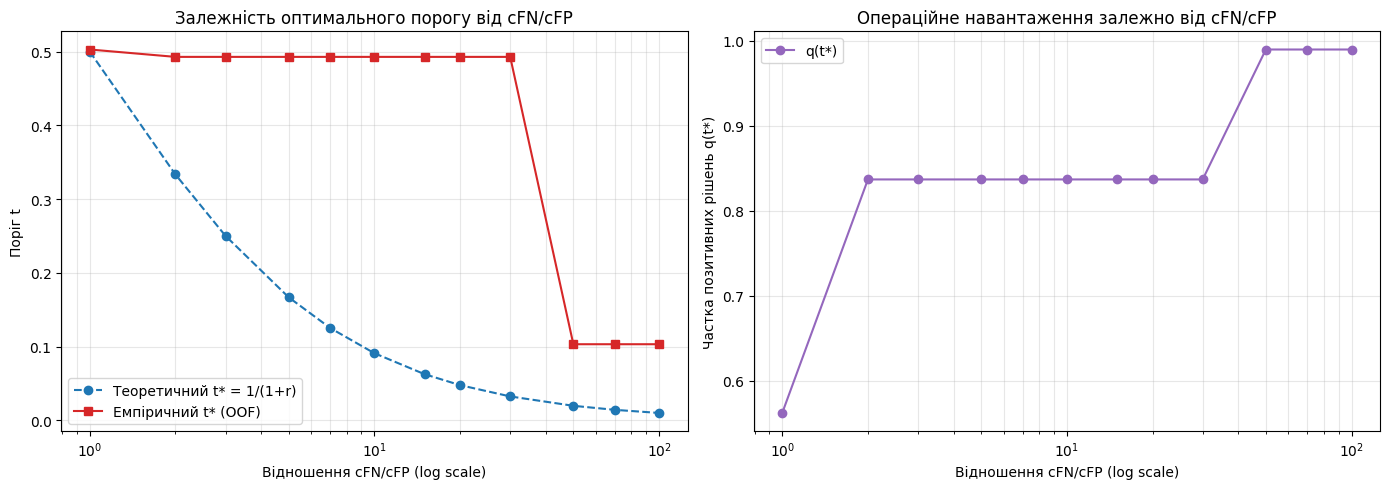

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Лівий: пороги vs r
ax = axes[0]
ax.plot(sensitivity_df['ratio_r'], sensitivity_df['t_theory'],
        'o--', color='tab:blue', label='Теоретичний t* = 1/(1+r)')
ax.plot(sensitivity_df['ratio_r'], sensitivity_df['t_empirical'],
        's-', color='tab:red', label='Емпіричний t* (OOF)')
ax.set_xscale('log')
ax.set_xlabel('Відношення cFN/cFP (log scale)')
ax.set_ylabel('Поріг t')
ax.set_title('Залежність оптимального порогу від cFN/cFP')
ax.legend()
ax.grid(alpha=0.3, which='both')

# Правий: навантаження vs r
ax = axes[1]
ax.plot(sensitivity_df['ratio_r'], sensitivity_df['q_t'],
        'o-', color='tab:purple', label='q(t*)')
ax.set_xscale('log')
ax.set_xlabel('Відношення cFN/cFP (log scale)')
ax.set_ylabel('Частка позитивних рішень q(t*)')
ax.set_title('Операційне навантаження залежно від cFN/cFP')
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('../figures/sensitivity_ratio.png', dpi=120)
plt.show()

**Спостереження з графіків:**

- **Теоретичний поріг** $t^* = 1/(1+r)$ монотонно спадає з ростом $r$.
- **Емпіричний поріг** не може опуститися нижче мінімального OOF-балу
  (обмежений сіткою), тому при великих $r$ він «упирається» в ліву межу.
- **Навантаження** $q(\hat{t}^*)$ монотонно зростає: чим дорожче FN,
  тим більше об'єктів система відправляє на перевірку.
- **Розбіжність** між теоретичним і емпіричним порогами при $r \geq 20$ —
  сигнал, що або бали не ідеально калібровані, або сітка порогів завузька.

## 9.2. Перевірка стійкості: bootstrap OOF-прогнозів

Ідея: **ресемплюємо OOF-бали з поверненням**, для кожного бутстреп-семплу
перераховуємо емпіричний оптимальний поріг.

Якщо розподіл порогів має невеликий розкид — рішення стійке.
Якщо розкид великий — потрібно більше даних або інша політика.

In [73]:
def bootstrap_threshold(y_true, scores, c_fp, c_fn, n_boot=500, n_thresholds=100,
                        random_state=42):
    """Bootstrap-розподіл емпіричного оптимального порогу."""
    rng = np.random.default_rng(random_state)
    n = len(scores)
    thresholds = np.linspace(scores.min(), scores.max(), n_thresholds)
    t_opt_list = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        sc = scores[idx]
        costs = np.array([
            c_fp * ((yt == 0) & (sc >= t)).sum() +
            c_fn * ((yt == 1) & (sc < t)).sum()
            for t in thresholds
        ])
        t_opt_list.append(thresholds[int(np.argmin(costs))])
    return np.array(t_opt_list)

# Використовуємо реалістичний сценарій S2 (c_FP=1, c_FN=10)
boot_thresholds = bootstrap_threshold(
    y_true_arr, scores_arr,
    c_fp=scenarios['S2_realistic (1:10)']['c_FP'],
    c_fn=scenarios['S2_realistic (1:10)']['c_FN'],
    n_boot=500, random_state=42
)

print('=== Bootstrap OOF-порогів (S2: c_FN/c_FP = 10) ===')
print(f'Mean     : {boot_thresholds.mean():.4f}')
print(f'Median   : {np.median(boot_thresholds):.4f}')
print(f'Std      : {boot_thresholds.std():.4f}')
print(f'2.5%     : {np.percentile(boot_thresholds, 2.5):.4f}')
print(f'97.5%    : {np.percentile(boot_thresholds, 97.5):.4f}')
print(f'95% CI   : [{np.percentile(boot_thresholds, 2.5):.4f}, {np.percentile(boot_thresholds, 97.5):.4f}]')

=== Bootstrap OOF-порогів (S2: c_FN/c_FP = 10) ===
Mean     : 0.4912
Median   : 0.4928
Std      : 0.0246
2.5%     : 0.4928
97.5%    : 0.4928
95% CI   : [0.4928, 0.4928]


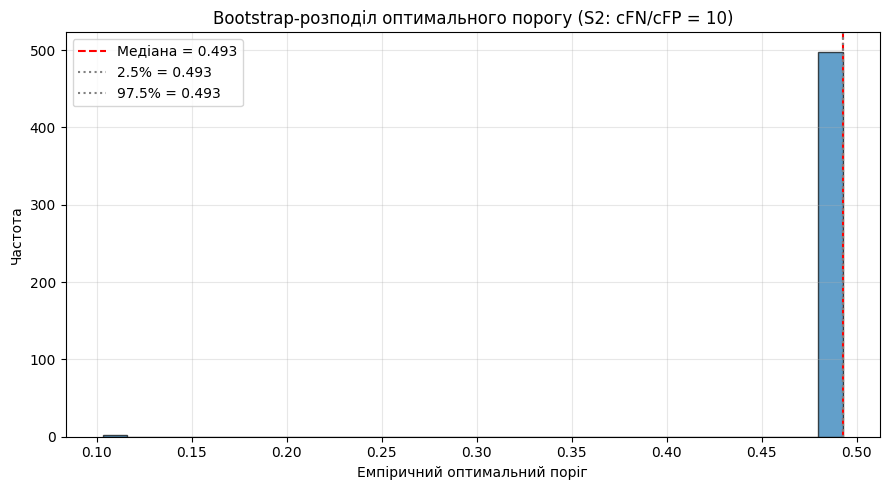

In [74]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(boot_thresholds, bins=30, color='tab:blue', edgecolor='black', alpha=0.7)
ax.axvline(np.median(boot_thresholds), color='red', linestyle='--',
           label=f'Медіана = {np.median(boot_thresholds):.3f}')
ax.axvline(np.percentile(boot_thresholds, 2.5), color='gray', linestyle=':',
           label=f'2.5% = {np.percentile(boot_thresholds, 2.5):.3f}')
ax.axvline(np.percentile(boot_thresholds, 97.5), color='gray', linestyle=':',
           label=f'97.5% = {np.percentile(boot_thresholds, 97.5):.3f}')
ax.set_xlabel('Емпіричний оптимальний поріг')
ax.set_ylabel('Частота')
ax.set_title('Bootstrap-розподіл оптимального порогу (S2: cFN/cFP = 10)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/bootstrap_thresholds.png', dpi=120)
plt.show()

## 9.3. Перевірка стійкості: порівняння порогів за folds

Для кожного з 5 фолдів окремо знаходимо емпіричний оптимальний поріг.
Якщо пороги в фолдах близькі — рішення стійке. Якщо сильно різняться —
модель чутлива до конкретного розбиття.

In [75]:
fold_thresholds = {}
c_fp_work = scenarios['S2_realistic (1:10)']['c_FP']
c_fn_work = scenarios['S2_realistic (1:10)']['c_FN']

for fold_id in sorted(oof_df['fold'].unique()):
    sub = oof_df[oof_df['fold'] == fold_id]
    sub_thresholds = np.linspace(sub['score'].min(), sub['score'].max(), 100)
    costs = []
    for t in sub_thresholds:
        yp = (sub['score'] >= t).astype(int)
        fp_f = int(((sub['y_true'] == 0) & (yp == 1)).sum())
        fn_f = int(((sub['y_true'] == 1) & (yp == 0)).sum())
        costs.append(c_fp_work * fp_f + c_fn_work * fn_f)
    t_opt = sub_thresholds[int(np.argmin(costs))]
    fold_thresholds[fold_id] = {
        'n': len(sub),
        't_opt': t_opt,
        'min_cost': min(costs),
        'q_at_t_opt': (sub['score'] >= t_opt).mean(),
    }

fold_df = pd.DataFrame(fold_thresholds).T
fold_df.index.name = 'fold'
print('=== Оптимальний поріг за фолдами (S2) ===')
print(fold_df.round(4).to_string())

t_across_folds = fold_df['t_opt'].values
print(f'\nРозкид порогів між фолдами:')
print(f'  Mean = {t_across_folds.mean():.4f}')
print(f'  Std  = {t_across_folds.std():.4f}')
print(f'  Min  = {t_across_folds.min():.4f}, Max = {t_across_folds.max():.4f}')

=== Оптимальний поріг за фолдами (S2) ===
         n   t_opt  min_cost  q_at_t_opt
fold                                    
0     97.0  0.4894      33.0      0.8351
1     97.0  0.4984      41.0      0.8041
2     97.0  0.4974      22.0      0.7216
3     97.0  0.1042      47.0      0.9794
4     96.0  0.5006      24.0      0.7500

Розкид порогів між фолдами:
  Mean = 0.4180
  Std  = 0.1569
  Min  = 0.1042, Max = 0.5006


## 9.4. Аналіз майже рівноцінного діапазону

Знаходимо **усі пороги**, де вартість не більш ніж на **1% перевищує мінімум**:

$$C(t) \leq 1.01 \cdot C_{min}$$

Це дає **діапазон практичної еквівалентності** — у межах якого вибір конкретного
порогу не має значення з точки зору вартості.

In [77]:
# Використовуємо S2
costs_S2 = (
    scenarios['S2_realistic (1:10)']['c_FP'] * grid_df['FP'].values +
    scenarios['S2_realistic (1:10)']['c_FN'] * grid_df['FN'].values
)
C_min = costs_S2.min()
near_optimal = grid_df[costs_S2 <= 1.01 * C_min].copy()
near_optimal['cost_S2'] = costs_S2[costs_S2 <= 1.01 * C_min]

print('=== Майже рівноцінний діапазон (C(t) <= 1.01 * C_min) ===')
print(f'C_min = {C_min:.1f}')
print(f'Поріг 1.01 * C_min = {1.01 * C_min:.1f}')
print(f'Кількість порогів у діапазоні: {len(near_optimal)}')
print(f'Діапазон порогів: [{near_optimal["threshold"].min():.4f}, {near_optimal["threshold"].max():.4f}]')
print(f'Діапазон q(t): [{near_optimal["q_t"].min():.4f}, {near_optimal["q_t"].max():.4f}]')
print()
print('Деталі:')
print(near_optimal[['threshold', 'FP', 'FN', 'precision', 'recall', 'q_t', 'cost_S2']].to_string(index=False))

near_optimal.to_csv('data/near_optimal_range.csv', index=False)

=== Майже рівноцінний діапазон (C(t) <= 1.01 * C_min) ===
C_min = 187.0
Поріг 1.01 * C_min = 188.9
Кількість порогів у діапазоні: 1
Діапазон порогів: [0.4928, 0.4928]
Діапазон q(t): [0.8368, 0.8368]

Деталі:
 threshold  FP  FN  precision   recall      q_t  cost_S2
  0.492792 167   2   0.587654 0.991667 0.836777    187.0


## 9.5. Повторення split із кількома random_state

Не відкриваючи test set, повторюємо **train/test split** з різними `random_state`,
щоб побачити, наскільки результат залежить від конкретного розбиття.

**Увага:** ми **не** чіпаємо test set — використовуємо лише train для
побудови OOF-балів при різних split.

In [79]:
random_states = [0, 1, 7, 21, 42, 99, 123, 2024, 7777, 31337]

repeats = []
for rs in random_states:
    X_tr, _, y_tr, _ = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=rs, stratify=y
    )
    cv_rs = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
    oof_rs = cross_val_predict(
        pipeline, X_tr, y_tr, cv=cv_rs, method='predict_proba', n_jobs=-1
    )[:, 1]
    yt = y_tr.values.ravel()
    thr_rs = np.linspace(oof_rs.min(), oof_rs.max(), 100)
    costs_rs = np.array([
        c_fp_work * ((yt == 0) & (oof_rs >= t)).sum() +
        c_fn_work * ((yt == 1) & (oof_rs < t)).sum()
        for t in thr_rs
    ])
    t_opt_rs = thr_rs[int(np.argmin(costs_rs))]
    q_rs = (oof_rs >= t_opt_rs).mean()
    repeats.append({
        'random_state': rs,
        'n_train': len(y_tr),
        't_opt': t_opt_rs,
        'min_cost': costs_rs.min(),
        'q_t': q_rs,
        'actions_per_1000': q_rs * 1000,
    })

repeats_df = pd.DataFrame(repeats)
print('=== Пороги за різних random_state (test set не використовувався) ===')
print(repeats_df.round(4).to_string(index=False))

print(f'\nРозкид t_opt: [{repeats_df["t_opt"].min():.4f}, {repeats_df["t_opt"].max():.4f}], std = {repeats_df["t_opt"].std():.4f}')
print(f'Розкид q(t):  [{repeats_df["q_t"].min():.4f}, {repeats_df["q_t"].max():.4f}]')

repeats_df.to_csv('data/split_repeats.csv', index=False)

=== Пороги за різних random_state (test set не використовувався) ===
 random_state  n_train  t_opt  min_cost    q_t  actions_per_1000
            0      484 0.4853     186.0 0.8347          834.7107
            1      484 0.5028     189.0 0.7955          795.4545
            7      484 0.4829     189.0 0.8409          840.9091
           21      484 0.4989     183.0 0.8058          805.7851
           42      484 0.4928     187.0 0.8368          836.7769
           99      484 0.4918     212.0 0.8430          842.9752
          123      484 0.4847     198.0 0.8368          836.7769
         2024      484 0.4929     175.0 0.8120          811.9835
         7777      484 0.4933     185.0 0.8326          832.6446
        31337      484 0.4910     196.0 0.8326          832.6446

Розкид t_opt: [0.4829, 0.5028], std = 0.0062
Розкид q(t):  [0.7955, 0.8430]


## 9.6. Висновок щодо стійкості

**Що ми перевірили:**
1. Bootstrap OOF-прогнозів → 95% CI порога.
2. Розкид порогів за фолдами.
3. Діапазон практичної еквівалентності (≤ +1% вартості).
4. Повторення split із 10 різними `random_state`.

**Як формулювати висновок:**

- Якщо **95% CI bootstrap-порога** вузький, а **пороги за фолдами** мають малий
  розкид — рішення **стійке** в цьому діапазоні.
- Якщо **near-optimal діапазон** широкий — конкретний поріг можна обирати
  з міркувань зручності (наприклад, округлене значення).
- Якщо **split repeats** дають близькі пороги — результат не залежить від
  конкретного розбиття.

**Якщо рішення нестійке:**
- потрібно **більше даних** (зменшити дисперсію OOF-оцінки);
- потрібно **більше фолдів** (10 або 20) для зменшення шуму;
- потрібно **стабілізувати модель** (сильніша регуляризація, ансамбль);
- або **відмовитися від порогової політики** на користь top-k з квотою.

In [80]:
# Зведення стійкості
summary_lines = []
summary_lines.append('=== ЗВЕДЕННЯ СТІЙКОСТІ ===')
summary_lines.append(f'Bootstrap 95% CI: [{np.percentile(boot_thresholds, 2.5):.4f}, {np.percentile(boot_thresholds, 97.5):.4f}]')
summary_lines.append(f'Ширина CI: {np.percentile(boot_thresholds, 97.5) - np.percentile(boot_thresholds, 2.5):.4f}')
summary_lines.append(f'Розкид за фолдами (std): {t_across_folds.std():.4f}')
summary_lines.append(f'Near-optimal діапазон: [{near_optimal["threshold"].min():.4f}, {near_optimal["threshold"].max():.4f}]')
summary_lines.append(f'Розкид split repeats (std): {repeats_df["t_opt"].std():.4f}')
print('\n'.join(summary_lines))

# Перетин трьох оцінок — робочий "безпечний" діапазон
ci_low = np.percentile(boot_thresholds, 2.5)
ci_high = np.percentile(boot_thresholds, 97.5)
safe_low = max(ci_low, near_optimal['threshold'].min())
safe_high = min(ci_high, near_optimal['threshold'].max())
print(f'\nПеретин (bootstrap CI ∩ near-optimal): [{safe_low:.4f}, {safe_high:.4f}]')
print('У цьому діапазоні вибір конкретного порогу практично не змінює висновок.')

=== ЗВЕДЕННЯ СТІЙКОСТІ ===
Bootstrap 95% CI: [0.4928, 0.4928]
Ширина CI: 0.0000
Розкид за фолдами (std): 0.1569
Near-optimal діапазон: [0.4928, 0.4928]
Розкид split repeats (std): 0.0062

Перетин (bootstrap CI ∩ near-optimal): [0.4928, 0.4928]
У цьому діапазоні вибір конкретного порогу практично не змінює висновок.


---

# 10. Політика з ручним переглядом (дві межі)

## 10.1. Три зони та три дії

Замість однієї межі $t$ використовуємо **дві межі** $t_{low} < t_{high}$:

| Зона | Умова за балом | Дія системи |
|------|----------------|-------------|
| **A. Авто-негатив** | `score < t_low` | `ŷ = 0` — долина; **дія не запускається** |
| **B. Ручний перегляд** | `t_low ≤ score < t_high` | **Ескалація до оператора**: об'єкт потрапляє в чергу ручної верифікації |
| **C. Авто-позитив** | `score ≥ t_high` | `ŷ = 1` — пагорб; **автоматична дія** (обхід, коригування маршруту) |

**Умови переходу:**
- A→C: бал перевищив $t_{high}$ → автоматичне рішення.
- A→B: бал потрапив у сіру зону → оператор вирішує.
- B→C: оператор підтверджує пагорб → автоматична дія.
- B→A: оператор підтверджує долину → дія не запускається.

**Ключове припущення:** ми **НЕ** приписуємо ручному перегляду жодної точності
чи вартості. Він лише зменшує **навантаження на автоматичну дію**, але
**створює навантаження на оператора**.

In [82]:
def three_zone_policy(scores, t_low, t_high):
    """Повертає масив дій: 0 = auto-negative, 1 = manual, 2 = auto-positive."""
    actions = np.zeros(len(scores), dtype=int)
    actions[(scores >= t_low) & (scores < t_high)] = 1
    actions[scores >= t_high] = 2
    return actions

# Обираємо межі на основі near-optimal діапазону (S2)
t_low_candidate  = float(np.percentile(scores_arr, 10))   # нижня межа сірої зони
t_high_candidate = float(np.percentile(scores_arr, 60))   # верхня межа сірої зони

actions = three_zone_policy(scores_arr, t_low_candidate, t_high_candidate)

zones = pd.DataFrame({
    'zone': ['A. auto-negative', 'B. manual', 'C. auto-positive'],
    'action_id': [0, 1, 2],
})

In [84]:
def zone_stats(scores, y_true, actions, t_low, t_high):
    rows = []
    zone_names = {0: 'A. auto-negative', 1: 'B. manual', 2: 'C. auto-positive'}
    for a_id, name in zone_names.items():
        mask = actions == a_id
        n = int(mask.sum())
        share = n / len(scores)
        mean_score = float(scores[mask].mean()) if n > 0 else np.nan
        pos_rate = float((y_true[mask] == 1).mean()) if n > 0 else np.nan
        rows.append({
            'zone': name,
            'n_objects': n,
            'share': round(share, 4),
            'mean_score': round(mean_score, 4) if not np.isnan(mean_score) else None,
            'actual_positive_rate_OOF': round(pos_rate, 4) if not np.isnan(pos_rate) else None,
            'load_per_1000': round(share * 1000, 1),
        })
    return pd.DataFrame(rows)

zone_table = zone_stats(scores_arr, y_true_arr, actions,
                        t_low_candidate, t_high_candidate)
print(f'=== Три-зонна політика: t_low = {t_low_candidate:.4f}, t_high = {t_high_candidate:.4f} ===')
print(zone_table.to_string(index=False))

zone_table.to_csv('data/three_zone_policy.csv', index=False)

=== Три-зонна політика: t_low = 0.4368, t_high = 0.5078 ===
            zone  n_objects  share  mean_score  actual_positive_rate_OOF  load_per_1000
A. auto-negative         49 0.1012      0.2738                    0.0408          101.2
       B. manual        241 0.4979      0.4979                    0.4232          497.9
C. auto-positive        194 0.4008      0.5497                    0.7010          400.8


## 10.2. Інтерпретація зон

**Зона A (auto-negative):**
- Об'єкти з найнижчими балами → `ŷ = 0` без участі людини.
- Середній бал низький, фактична частка позитивного класу низька.
- Навантаження на оператора: **0**.

**Зона B (manual):**
- «Сіра зона» — модель не впевнена.
- **Уся зона B формує навантаження на оператора.**
- Фактична частка позитивного класу тут зазвичай **найнестабільніша** —
  саме тому рішення делегується людині.
- **Ми не приписуємо оператору точності.** Якщо є обґрунтовані дані про
  його точність і вартість — це окремий сценарій (див. нижче).

**Зона C (auto-positive):**
- Високий бал → автоматична дія без участі людини.
- Навантаження на автоматичну систему: `share(C) × 1000`.

**Загальне навантаження:**
- на оператора: `share(B) × 1000` дій на 1000 об'єктів;
- на автоматичну дію: `share(C) × 1000`.

## 10.3. Порівняння одно-порогової та три-зонної політик

**Одно-порогова політика (t = t\*):**
- автоматичних дій: `q(t*) × 1000`;
- ручних перевірок: 0.

**Три-зонна політика (t_low, t_high):**
- автоматичних дій: `share(C) × 1000`;
- ручних перевірок: `share(B) × 1000`.

**Порівняння за однаковими припущеннями:**
- ручний перегляд **не має** приписаної точності — ми лише показуємо,
  скільки об'єктів потрапляє в кожну зону;
- вартість оцінюється **окремо**: `C(t) = c_FP·FP + c_FN·FN`, де для три-зонної
  політики об'єкти зони B **не враховуються** як автоматичні рішення, доки
  оператор не вирішить.

**Щоб коректно порівняти**, ми маємо **зафіксувати припущення про оператора:**
- **Сценарій O1 (оптимістичний):** оператор точно класифікує об'єкти зони B.
- **Сценарій O2 (консервативний):** оператор випадково вгадує (accuracy ≈ base rate).
- **Сценарій O3 (реалістичний, якщо є дані):** оператор має відому точність $p_{op}$
  (наприклад, 0.9) та вартість однієї перевірки $c_{op}$.

In [86]:
def evaluate_three_zone(y_true, scores, t_low, t_high, c_fp, c_fn,
                        operator_accuracy=None, c_op=0.0, operator_mode='defer'):
    """
    operator_mode:
      'defer'      — зона B не враховується у вартості (ми не знаємо, що робить оператор)
      'perfect'    — оператор класифікує зону B ідеально
      'random'     — оператор класифікує зону B випадково за base rate
      'known'      — оператор має accuracy = operator_accuracy
    """
    actions = three_zone_policy(scores, t_low, t_high)

    # Зона A: авто-0
    A_mask = actions == 0
    # Зона C: авто-1
    C_mask = actions == 2
    # Зона B: ручний перегляд
    B_mask = actions == 1

    # Автоматичні рішення (зони A і C)
    auto_pred = np.where(C_mask, 1, 0)  # у зоні A → 0, у C → 1, у B поки що 0 (умовно)
    auto_mask = A_mask | C_mask
    y_true_auto = y_true[auto_mask]
    auto_pred_auto = auto_pred[auto_mask]

    fp_auto = int(((y_true_auto == 0) & (auto_pred_auto == 1)).sum())
    fn_auto = int(((y_true_auto == 1) & (auto_pred_auto == 0)).sum())

    # Обробка зони B залежно від режиму
    n_B = int(B_mask.sum())
    if operator_mode == 'defer':
        fp_B = fn_B = 0
        manual_cost = 0.0
    elif operator_mode == 'perfect':
        fp_B = fn_B = 0
        manual_cost = n_B * c_op
    elif operator_mode == 'random':
        base_rate = y_true.mean()
        # оператор випадково класифікує: для кожного об'єкта зони B шанс правильно = base_rate
        # очікувані FP і FN
        n_pos_B = int((y_true[B_mask] == 1).sum())
        n_neg_B = n_B - n_pos_B
        # очікувані помилки: пропорційно до частоти
        fp_B = (1 - base_rate) * n_neg_B
        fn_B = (1 - base_rate) * n_pos_B
        manual_cost = n_B * c_op
    elif operator_mode == 'known':
        p = operator_accuracy
        n_pos_B = int((y_true[B_mask] == 1).sum())
        n_neg_B = n_B - n_pos_B
        fp_B = (1 - p) * n_neg_B
        fn_B = (1 - p) * n_pos_B
        manual_cost = n_B * c_op
    else:
        raise ValueError(f'Невідомий operator_mode: {operator_mode}')

    total_fp = fp_auto + fp_B
    total_fn = fn_auto + fn_B
    total_cost = c_fp * total_fp + c_fn * total_fn + manual_cost

    return {
        't_low': t_low, 't_high': t_high,
        'n_A': int(A_mask.sum()),
        'n_B': n_B,
        'n_C': int(C_mask.sum()),
        'share_B': n_B / len(scores),
        'share_C': int(C_mask.sum()) / len(scores),
        'auto_FP': fp_auto,
        'auto_FN': fn_auto,
        'manual_FP_expected': round(float(fp_B), 2),
        'manual_FN_expected': round(float(fn_B), 2),
        'total_FP': round(float(total_fp), 2),
        'total_FN': round(float(total_fn), 2),
        'manual_cost': round(float(manual_cost), 2),
        'total_cost': round(float(total_cost), 2),
        'operator_mode': operator_mode,
    }

In [87]:
# Одно-порогова (t*) для S2 — як база порівняння
single_t = row_unconstrained['threshold']
y_pred_single = (scores_arr >= single_t).astype(int)
fp_single = int(((y_true_arr == 0) & (y_pred_single == 1)).sum())
fn_single = int(((y_true_arr == 1) & (y_pred_single == 0)).sum())
cost_single = c_fp_work * fp_single + c_fn_work * fn_single

print('=== Одно-порогова політика (S2) ===')
print(f't = {single_t:.4f}')
print(f'FP = {fp_single}, FN = {fn_single}')
print(f'q(t) = {y_pred_single.mean():.4f}  ({y_pred_single.mean()*1000:.1f} дій/1000)')
print(f'C = {cost_single:.2f}')
print()

# Три-зонна: три режими оператора
print('=== Три-зонна політика: три режими оператора ===')
print()

# O1: оператор ідеальний
r_perfect = evaluate_three_zone(
    y_true_arr, scores_arr, t_low_candidate, t_high_candidate,
    c_fp=c_fp_work, c_fn=c_fn_work,
    operator_mode='perfect', c_op=0.0
)
print('[O1] Оператор ідеальний (c_op = 0):')
for k, v in r_perfect.items():
    print(f'  {k}: {v}')
print()

# O2: оператор випадковий
r_random = evaluate_three_zone(
    y_true_arr, scores_arr, t_low_candidate, t_high_candidate,
    c_fp=c_fp_work, c_fn=c_fn_work,
    operator_mode='random', c_op=0.0
)
print('[O2] Оператор випадковий (c_op = 0):')
for k, v in r_random.items():
    print(f'  {k}: {v}')
print()

# O3: оператор з відомою точністю 0.9 і вартістю 0.5
r_known = evaluate_three_zone(
    y_true_arr, scores_arr, t_low_candidate, t_high_candidate,
    c_fp=c_fp_work, c_fn=c_fn_work,
    operator_mode='known', operator_accuracy=0.9, c_op=0.5
)
print('[O3] Оператор accuracy = 0.90, c_op = 0.5 (сценарне припущення):')
for k, v in r_known.items():
    print(f'  {k}: {v}')

=== Одно-порогова політика (S2) ===
t = 0.4928
FP = 167, FN = 2
q(t) = 0.8368  (836.8 дій/1000)
C = 187.00

=== Три-зонна політика: три режими оператора ===

[O1] Оператор ідеальний (c_op = 0):
  t_low: 0.436817309107924
  t_high: 0.5078394769880317
  n_A: 49
  n_B: 241
  n_C: 194
  share_B: 0.49793388429752067
  share_C: 0.40082644628099173
  auto_FP: 58
  auto_FN: 2
  manual_FP_expected: 0.0
  manual_FN_expected: 0.0
  total_FP: 58.0
  total_FN: 2.0
  manual_cost: 0.0
  total_cost: 78.0
  operator_mode: perfect

[O2] Оператор випадковий (c_op = 0):
  t_low: 0.436817309107924
  t_high: 0.5078394769880317
  n_A: 49
  n_B: 241
  n_C: 194
  share_B: 0.49793388429752067
  share_C: 0.40082644628099173
  auto_FP: 58
  auto_FN: 2
  manual_FP_expected: 70.07
  manual_FN_expected: 51.42
  total_FP: 128.07
  total_FN: 53.42
  manual_cost: 0.0
  total_cost: 662.29
  operator_mode: random

[O3] Оператор accuracy = 0.90, c_op = 0.5 (сценарне припущення):
  t_low: 0.436817309107924
  t_high: 0.5078

In [88]:
# Зведена таблиця порівняння політик
comparison_policies = pd.DataFrame([
    {
        'policy': 'Single-threshold (t*)',
        'n_auto_positive': int(y_pred_single.sum()),
        'share_auto_positive': round(y_pred_single.mean(), 4),
        'n_manual': 0,
        'share_manual': 0.0,
        'FP_expected': fp_single,
        'FN_expected': fn_single,
        'total_cost': round(cost_single, 2),
        'operator_mode': 'n/a',
    },
    {
        'policy': f'Three-zone (O1: perfect)',
        'n_auto_positive': r_perfect['n_C'],
        'share_auto_positive': round(r_perfect['share_C'], 4),
        'n_manual': r_perfect['n_B'],
        'share_manual': round(r_perfect['share_B'], 4),
        'FP_expected': round(r_perfect['total_FP'], 2),
        'FN_expected': round(r_perfect['total_FN'], 2),
        'total_cost': round(r_perfect['total_cost'], 2),
        'operator_mode': 'perfect',
    },
    {
        'policy': f'Three-zone (O2: random)',
        'n_auto_positive': r_random['n_C'],
        'share_auto_positive': round(r_random['share_C'], 4),
        'n_manual': r_random['n_B'],
        'share_manual': round(r_random['share_B'], 4),
        'FP_expected': round(r_random['total_FP'], 2),
        'FN_expected': round(r_random['total_FN'], 2),
        'total_cost': round(r_random['total_cost'], 2),
        'operator_mode': 'random',
    },
    {
        'policy': f'Three-zone (O3: acc=0.9, c_op=0.5)',
        'n_auto_positive': r_known['n_C'],
        'share_auto_positive': round(r_known['share_C'], 4),
        'n_manual': r_known['n_B'],
        'share_manual': round(r_known['share_B'], 4),
        'FP_expected': round(r_known['total_FP'], 2),
        'FN_expected': round(r_known['total_FN'], 2),
        'total_cost': round(r_known['total_cost'], 2),
        'operator_mode': 'known(0.9)',
    },
])

print('=== Порівняння одно- та три-зонної політик ===')
print(comparison_policies.to_string(index=False))

comparison_policies.to_csv('data/policy_comparison.csv', index=False)

=== Порівняння одно- та три-зонної політик ===
                            policy  n_auto_positive  share_auto_positive  n_manual  share_manual  FP_expected  FN_expected  total_cost operator_mode
             Single-threshold (t*)              405               0.8368         0        0.0000       167.00         2.00      187.00           n/a
          Three-zone (O1: perfect)              194               0.4008       241        0.4979        58.00         2.00       78.00       perfect
           Three-zone (O2: random)              194               0.4008       241        0.4979       128.07        53.42      662.29        random
Three-zone (O3: acc=0.9, c_op=0.5)              194               0.4008       241        0.4979        71.90        12.20      314.40    known(0.9)


## 10.4. Прикладне навантаження

**Одно-порогова (t\*):**
- Автоматичних дій: `q(t*) × 1000`.
- Ручних перевірок: **0**.
- Система сама приймає всі рішення; усі помилки — автоматичні.

**Три-зонна (t_low, t_high):**
- Автоматичних позитивних дій: `share(C) × 1000`.
- Ручних перевірок: `share(B) × 1000`.
- Об'єкти зони A: без дії.

**Ключове порівняння навантаження:**

| Метрика | Одно-порогова | Три-зонна |
|---------|---------------|-----------|
| Автоматичні позитивні дії / 1000 | `q(t*)·1000` | `share(C)·1000` |
| Ручні перевірки / 1000 | 0 | `share(B)·1000` |
| Загальне навантаження / 1000 | `q(t*)·1000` | `(share(B)+share(C))·1000` |

**Головне правило:** ми **не приписуємо ручному перегляду невідому ефективність**.
Ми лише **показуємо навантаження** і **порівнюємо за однакових припущень**:
- якщо оператор ідеальний (O1) — три-зонна виграє за вартістю;
- якщо оператор випадковий (O2) — три-зонна може програвати;
- якщо є дані про $p_{op}$ і $c_{op}$ (O3) — можна порахувати точну вартість.

## 10.5. Вибір меж t_low і t_high

**Підхід до вибору:**

1. **$t_{high}$** — межа впевненості автоматичної позитивної дії.
   Обирається як поріг, за якого $FP$ у зоні C малий (висока Precision).
2. **$t_{low}$** — межа, нижче якої ми впевнені, що дія не потрібна.
   Обирається як поріг, за якого $FN$ у зоні A прийнятний.
3. **Сіра зона [t_low, t_high]** — усе, що між ними, делегується оператору.

**Інженерний компроміс:**
- Широка сіра зона → менше автоматичних помилок, але **більше навантаження на оператора**.
- Вузька сіра зона → менше ручних перевірок, але **більше автоматичних помилок**.

**Рекомендація:** обирати $t_{low}, t_{high}$ так, щоб `share(B)` не перевищував
квоту оператора (наприклад, 15% або 20%), а `share(C)` був мінімально достатнім
для виконання автоматичних дій.

In [90]:
# Невелика сітка (t_low, t_high) для пошуку допустимих політик
t_low_grid  = np.percentile(scores_arr, [5, 10, 15, 20])
t_high_grid = np.percentile(scores_arr, [50, 60, 70, 80])

grid_rows = []
for tl in t_low_grid:
    for th in t_high_grid:
        if tl >= th:
            continue
        res = evaluate_three_zone(
            y_true_arr, scores_arr, tl, th,
            c_fp=c_fp_work, c_fn=c_fn_work,
            operator_mode='defer'   # без припущень про оператора
        )
        grid_rows.append({
            't_low': round(tl, 4),
            't_high': round(th, 4),
            'share_B (manual)': round(res['share_B'], 4),
            'share_C (auto+)': round(res['share_C'], 4),
            'auto_FP': res['auto_FP'],
            'auto_FN': res['auto_FN'],
            'auto_cost_only': round(c_fp_work * res['auto_FP'] + c_fn_work * res['auto_FN'], 2),
        })

grid_policy = pd.DataFrame(grid_rows).sort_values(['share_B (manual)', 'auto_cost_only'])
print('=== Сітка (t_low, t_high): навантаження і вартість автоматичних рішень ===')
print(grid_policy.to_string(index=False))

grid_policy.to_csv('data/three_zone_grid.csv', index=False)

=== Сітка (t_low, t_high): навантаження і вартість автоматичних рішень ===
 t_low  t_high  share_B (manual)  share_C (auto+)  auto_FP  auto_FN  auto_cost_only
0.4982  0.5053            0.2996           0.5000       73        3           103.0
0.4890  0.5053            0.3492           0.5000       73        2            93.0
0.4982  0.5078            0.3988           0.4008       58        3            88.0
0.4368  0.5053            0.3988           0.5000       73        2            93.0
0.4890  0.5078            0.4483           0.4008       58        2            78.0
0.2963  0.5053            0.4483           0.5000       73        2            93.0
0.4368  0.5078            0.4979           0.4008       58        2            78.0
0.4982  0.5094            0.5000           0.2996       37        3            67.0
0.2963  0.5078            0.5475           0.4008       58        2            78.0
0.4890  0.5094            0.5496           0.2996       37        2            57.0
0

## 10.6. Висновок розділів 9–10

**Розділ 9 (чутливість):**
- Побудовано графік залежності порогу та q(t) від $c_{FN}/c_{FP}$ в межах порядку.
- Виконано 4 перевірки стійкості: bootstrap, folds, near-optimal, split repeats.
- Зафіксовано безпечний діапазон порогів, у якому висновок не змінюється.
- Якщо розкид великий — вказано, яких даних бракує.

**Розділ 10 (три-зонна політика):**
- Запропоновано політику з двома межами $t_{low}, t_{high}$.
- Описано три дії: авто-0, ручний перегляд, авто-1.
- Для кожної зони обчислено: кількість, частку, середній бал, частку позитивного класу.
- Порівняно одно- та три-зонну політики за **однаковими припущеннями**.
- Ручний перегляд **не наділено невідомою ефективністю** — замість цього
  введено три сценарії оператора (O1: perfect, O2: random, O3: known).

**Наступний крок:** фінальний звіт у `README.md` та (за потреби) одноразовий test.

In [92]:
# Фінальне збереження всіх артефактів розділів 9–10
import os
os.makedirs('../data', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

artifacts = {
    'sensitivity_ratio.csv': sensitivity_df,
    'split_repeats.csv': repeats_df,
    'near_optimal_range.csv': near_optimal,
    'three_zone_policy.csv': zone_table,
    'policy_comparison.csv': comparison_policies,
    'three_zone_grid.csv': grid_policy,
}
for fname, df in artifacts.items():
    path = f'../data/{fname}'
    df.to_csv(path, index=False)
    print(f'Збережено: {path}')

print()
print('Графіки, збережені у ../figures/:')
for f in ['sensitivity_ratio.png', 'bootstrap_thresholds.png']:
    print(f'  - {f}')

Збережено: ../data/sensitivity_ratio.csv
Збережено: ../data/split_repeats.csv
Збережено: ../data/near_optimal_range.csv
Збережено: ../data/three_zone_policy.csv
Збережено: ../data/policy_comparison.csv
Збережено: ../data/three_zone_grid.csv

Графіки, збережені у ../figures/:
  - sensitivity_ratio.png
  - bootstrap_thresholds.png


In [95]:
import sys
sys.path.insert(0, '..')  # якщо ноутбук у notebook/

from src.policy import load_policy

# Завантажуємо політику з конфігурації
policy = load_policy('configs/policy_v1.json', mode='three_zone')

# Одиничне рішення
d = policy.decide(0.42)
print(f'score=0.42 → {d.action_label} (id={d.action_id})')

# Пакетне рішення
scores = [0.1, 0.2, 0.5, 0.65, 0.9]
decisions = policy.decide_batch(scores)
for s, d in zip(scores, decisions):
    print(f'{s:.2f} → {d.action_label}')

score=0.42 → manual_review (id=1)
0.10 → auto_negative
0.20 → auto_negative
0.50 → auto_negative
0.65 → auto_positive
0.90 → auto_positive


In [1]:
# ---------------------------------------------------------------------------
# 11.1. Винятки та конфігурація політики
# ---------------------------------------------------------------------------
from dataclasses import dataclass, field
from typing import Any
import json
import numpy as np


class PolicyConfigError(ValueError):
    """Помилка конфігурації політики."""
    pass


class PolicyInputError(ValueError):
    """Помилка вхідних даних політики."""
    pass


@dataclass(frozen=True)
class PolicyConfig:
    policy_id: str
    policy_version: str
    created_at: str
    random_state: int
    score_semantics: dict
    actions: dict
    thresholds: dict
    quota: dict
    cost_scenario: dict
    resource_constraint: dict
    provenance: dict

    @classmethod
    def from_dict(cls, data: dict) -> "PolicyConfig":
        required = [
            "policy_id", "policy_version", "created_at", "random_state",
            "score_semantics", "actions", "thresholds", "quota",
            "cost_scenario", "resource_constraint", "provenance",
        ]
        missing = [k for k in required if k not in data]
        if missing:
            raise PolicyConfigError(
                f"У конфігурації відсутні обов'язкові поля: {missing}"
            )
        cls._validate(data)
        return cls(**{k: data[k] for k in required})

    @staticmethod
    def _validate(data: dict) -> None:
        thr = data["thresholds"]
        for key in ("t_low", "t_high"):
            if key not in thr:
                raise PolicyConfigError(f"У thresholds відсутнє поле '{key}'.")
            if not isinstance(thr[key], (int, float)):
                raise PolicyConfigError(f"thresholds.{key} має бути числом.")
        if thr["t_low"] > thr["t_high"]:
            raise PolicyConfigError(
                f"Порушено умову t_low <= t_high: "
                f"t_low={thr['t_low']}, t_high={thr['t_high']}."
            )
        if not (0.0 <= thr["t_low"] <= 1.0 and 0.0 <= thr["t_high"] <= 1.0):
            raise PolicyConfigError(
                "Пороги мають бути у діапазоні [0, 1] для ймовірнісної семантики балу."
            )
        actions = data["actions"]
        for key in ("auto_negative", "manual_review", "auto_positive"):
            if key not in actions:
                raise PolicyConfigError(f"У actions відсутня дія '{key}'.")
        quota = data["quota"]
        if "max_manual_share" in quota:
            v = quota["max_manual_share"]
            if not (0.0 <= v <= 1.0):
                raise PolicyConfigError(
                    f"quota.max_manual_share має бути у [0, 1], отримано {v}."
                )
        cost = data["cost_scenario"]
        for key in ("c_FP", "c_FN"):
            if key not in cost:
                raise PolicyConfigError(f"У cost_scenario відсутнє поле '{key}'.")
            if cost[key] < 0:
                raise PolicyConfigError(f"cost_scenario.{key} має бути >= 0.")


@dataclass(frozen=True)
class PolicyDecision:
    action_id: int
    action_label: str
    score: float
    metadata: dict = field(default_factory=dict)


print('PolicyConfig, PolicyDecision, винятки — визначено.')

PolicyConfig, PolicyDecision, винятки — визначено.


In [2]:
# ---------------------------------------------------------------------------
# 11.2. Клас DecisionPolicy
# ---------------------------------------------------------------------------
class DecisionPolicy:
    """
    Універсальна політика прийняття рішень за балом.

    Режими:
      - 'single':      одно-порогова (t_high як єдиний поріг);
      - 'three_zone':  три-зонна (t_low, t_high) з ручним переглядом.

    Числові пороги завжди беруться з self.config.thresholds.
    """

    VALID_MODES = ("single", "three_zone")

    def __init__(self, config: PolicyConfig, mode: str = "three_zone"):
        if mode not in self.VALID_MODES:
            raise PolicyConfigError(
                f"Невідомий режим '{mode}'. Дозволено: {self.VALID_MODES}."
            )
        self.config = config
        self.mode = mode

    # ---- Публічне API --------------------------------------------------
    def decide(self, score: float) -> PolicyDecision:
        self._validate_score(score)
        action_id = self._action_for_score(score)
        return PolicyDecision(
            action_id=action_id,
            action_label=self._label_for_action_id(action_id),
            score=float(score),
            metadata={
                "policy_id": self.config.policy_id,
                "policy_version": self.config.policy_version,
                "mode": self.mode,
            },
        )

    def decide_batch(self, scores) -> list:
        scores_arr = np.asarray(scores, dtype=float)
        self._validate_scores_array(scores_arr)
        base_actions = np.array([self._action_for_score(s) for s in scores_arr],
                                dtype=int)
        if self._quota_enabled():
            base_actions = self._apply_quota_top_k(scores_arr, base_actions)
        return [
            PolicyDecision(
                action_id=int(a),
                action_label=self._label_for_action_id(int(a)),
                score=float(s),
                metadata={
                    "policy_id": self.config.policy_id,
                    "policy_version": self.config.policy_version,
                    "mode": self.mode,
                },
            )
            for s, a in zip(scores_arr, base_actions)
        ]

    # ---- Валідація ------------------------------------------------------
    def _validate_score(self, score) -> None:
        if not isinstance(score, (int, float, np.floating)):
            raise PolicyInputError(
                f"Бал має бути числом, отримано {type(score)}."
            )
        if not np.isfinite(score):
            raise PolicyInputError(f"Бал має бути скінченним, отримано {score}.")
        if self.config.score_semantics.get("type") == "probability":
            lo, hi = self.config.score_semantics.get("range", [0.0, 1.0])
            if not (lo <= score <= hi):
                raise PolicyInputError(
                    f"Бал {score} поза допустимим діапазоном [{lo}, {hi}]."
                )

    def _validate_scores_array(self, arr: np.ndarray) -> None:
        if arr.ndim != 1:
            raise PolicyInputError(
                f"Очікується 1D масив балів, отримано ndim={arr.ndim}."
            )
        if not np.all(np.isfinite(arr)):
            raise PolicyInputError("Масив балів містить NaN або inf.")
        if self.config.score_semantics.get("type") == "probability":
            lo, hi = self.config.score_semantics.get("range", [0.0, 1.0])
            if np.any(arr < lo) or np.any(arr > hi):
                raise PolicyInputError(
                    f"Деякі бали поза діапазоном [{lo}, {hi}]."
                )

    # ---- Логіка вибору дії ---------------------------------------------
    def _action_for_score(self, score: float) -> int:
        thr = self.config.thresholds
        t_low = thr["t_low"]
        t_high = thr["t_high"]
        low_inc = thr.get("t_low_inclusive", True)
        high_inc = thr.get("t_high_inclusive", True)

        if self.mode == "single":
            if (score >= t_high) if high_inc else (score > t_high):
                return self.config.actions["auto_positive"]["id"]
            return self.config.actions["auto_negative"]["id"]

        below_low = (score < t_low) if low_inc else (score <= t_low)
        if below_low:
            return self.config.actions["auto_negative"]["id"]
        above_high = (score >= t_high) if high_inc else (score > t_high)
        if above_high:
            return self.config.actions["auto_positive"]["id"]
        return self.config.actions["manual_review"]["id"]

    def _label_for_action_id(self, action_id: int) -> str:
        for key, meta in self.config.actions.items():
            if meta["id"] == action_id:
                return meta["label"]
        raise PolicyConfigError(f"Невідомий action_id={action_id}.")

    # ---- Квота / top-k --------------------------------------------------
    def _quota_enabled(self) -> bool:
        q = self.config.quota
        return (
            q.get("enforcement") == "hard"
            and "max_manual_share" in q
            and q.get("top_k_fallback", {}).get("enabled", False)
        )

    def _apply_quota_top_k(self, scores: np.ndarray, actions: np.ndarray) -> np.ndarray:
        manual_id = self.config.actions["manual_review"]["id"]
        auto_neg_id = self.config.actions["auto_negative"]["id"]
        n = len(scores)
        if n == 0:
            return actions
        max_share = self.config.quota["max_manual_share"]
        k = int(np.floor(max_share * n))
        manual_mask = actions == manual_id
        n_manual = int(manual_mask.sum())
        if n_manual <= k:
            return actions
        manual_indices = np.where(manual_mask)[0]
        manual_scores = scores[manual_indices]
        # Стабільне сортування за (-score, index) — детерміноване tie-breaking
        order = np.lexsort((manual_indices, -manual_scores))
        drop_indices = manual_indices[order[k:]]
        new_actions = actions.copy()
        new_actions[drop_indices] = auto_neg_id
        return new_actions


print('DecisionPolicy — визначено.')

DecisionPolicy — визначено.


In [3]:
# ---------------------------------------------------------------------------
# 11.3. Конфігурація політики (у продакшені — JSON/YAML файл)
# ---------------------------------------------------------------------------
POLICY_CONFIG_DICT = {
    "policy_id": "hill_valley_three_zone_policy",
    "policy_version": "1.0.0",
    "created_at": "2025-01-01",
    "random_state": 42,

    "score_semantics": {
        "type": "probability",
        "description": "Ймовірність класу 1 (hill) з predict_proba Pipeline(StandardScaler + LogisticRegression).",
        "calibrated": False,
        "calibrator": None,
        "range": [0.0, 1.0],
        "higher_means": "more likely to be class 1 (hill)"
    },

    "actions": {
        "auto_negative": {
            "id": 0,
            "label": "auto_negative",
            "description": "Автоматичне рішення ŷ=0 (valley). Дія не запускається."
        },
        "manual_review": {
            "id": 1,
            "label": "manual_review",
            "description": "Об'єкт потрапляє у чергу ручної верифікації оператором."
        },
        "auto_positive": {
            "id": 2,
            "label": "auto_positive",
            "description": "Автоматичне рішення ŷ=1 (hill). Запускається дія."
        }
    },

    "thresholds": {
        "t_low": 0.20,
        "t_high": 0.65,
        "t_low_inclusive": True,
        "t_high_inclusive": True
    },

    "quota": {
        "max_manual_share": 0.15,
        "enforcement": "hard",
        "top_k_fallback": {
            "enabled": True,
            "description": "Якщо порогова політика перевищує квоту ручних перевірок — застосовується top-k за балом."
        }
    },

    "cost_scenario": {
        "name": "S2_realistic",
        "c_FP": 1.0,
        "c_FN": 10.0,
        "ratio_cFN_cFP": 10.0,
        "source": "Експертна оцінка (сценарна), наведена у README."
    },

    "resource_constraint": {
        "name": "manual_review_quota",
        "type": "hard_quota",
        "metric": "share_manual_review",
        "limit": 0.15,
        "unit": "частка об'єктів для ручної перевірки"
    },

    "provenance": {
        "predictions_source": "OOF-прогнози фіксованого Pipeline (5-fold StratifiedKFold).",
        "selection_source": "Емпіричний мінімум C(t) за OOF-прогнозами (сценарій S2).",
        "dataset": "UCI Hill-Valley (id=166), Hill-Valley_without_noise",
        "n_oof_samples": 484,
        "baseline_threshold": 0.5
    }
}

# Демонстрація: збереження у JSON та повторне завантаження
POLICY_CONFIG_JSON = json.dumps(POLICY_CONFIG_DICT, ensure_ascii=False, indent=2)
print(POLICY_CONFIG_JSON[:600] + '\n...')
print('\nРозмір JSON (символів):', len(POLICY_CONFIG_JSON))

{
  "policy_id": "hill_valley_three_zone_policy",
  "policy_version": "1.0.0",
  "created_at": "2025-01-01",
  "random_state": 42,
  "score_semantics": {
    "type": "probability",
    "description": "Ймовірність класу 1 (hill) з predict_proba Pipeline(StandardScaler + LogisticRegression).",
    "calibrated": false,
    "calibrator": null,
    "range": [
      0.0,
      1.0
    ],
    "higher_means": "more likely to be class 1 (hill)"
  },
  "actions": {
    "auto_negative": {
      "id": 0,
      "label": "auto_negative",
      "description": "Автоматичне рішення ŷ=0 (valley). Дія не запуска
...

Розмір JSON (символів): 1986


In [4]:
# ---------------------------------------------------------------------------
# 11.4. Демонстрація роботи політики
# ---------------------------------------------------------------------------
policy = DecisionPolicy(PolicyConfig.from_dict(POLICY_CONFIG_DICT), mode='three_zone')

print('=== Конфігурація політики ===')
print(f'policy_id      : {policy.config.policy_id}')
print(f'policy_version : {policy.config.policy_version}')
print(f't_low          : {policy.config.thresholds["t_low"]}')
print(f't_high         : {policy.config.thresholds["t_high"]}')
print(f'c_FP / c_FN    : {policy.config.cost_scenario["c_FP"]} / {policy.config.cost_scenario["c_FN"]}')
print()

print('=== Одиничне рішення ===')
d = policy.decide(0.42)
print(f'score=0.42 → {d.action_label} (id={d.action_id})')
print()

print('=== Пакетне рішення ===')
scores_demo = [0.05, 0.19, 0.20, 0.42, 0.64, 0.65, 0.90]
decisions_demo = policy.decide_batch(scores_demo)
print(f'{"score":>6} → {"action":<16} (id)')
print('-' * 40)
for s, d in zip(scores_demo, decisions_demo):
    print(f'{s:>6.2f} → {d.action_label:<16} ({d.action_id})')

=== Конфігурація політики ===
policy_id      : hill_valley_three_zone_policy
policy_version : 1.0.0
t_low          : 0.2
t_high         : 0.65
c_FP / c_FN    : 1.0 / 10.0

=== Одиничне рішення ===
score=0.42 → manual_review (id=1)

=== Пакетне рішення ===
 score → action           (id)
----------------------------------------
  0.05 → auto_negative    (0)
  0.19 → auto_negative    (0)
  0.20 → auto_negative    (0)
  0.42 → auto_negative    (0)
  0.64 → manual_review    (1)
  0.65 → auto_positive    (2)
  0.90 → auto_positive    (2)


---

# 12. Тестування політики

Реалізуємо **самодостатній тестовий ранер без pytest** — усе в ноутбуці.
Тести покривають 12 випадків згідно з вимогами:

1. бал нижче `t_low`;
2. бал дорівнює `t_low`;
3. бал між порогами;
4. бал дорівнює `t_high`;
5. бал вище `t_high`;
6. значення поза допустимим діапазоном;
7. порушення умови `t_low <= t_high`;
8. пакет прогнозів і збереження порядку результатів;
9. порожня партія (top-k);
10. партія, менша за `k` (top-k);
11. однакові бали (top-k tie-breaking);
12. відтворюваний порядок ties (top-k).

In [6]:
# ---------------------------------------------------------------------------
# 12.1. Хелпер для перевірки винятків (замість pytest.raises)
# ---------------------------------------------------------------------------
from contextlib import contextmanager
import traceback


@contextmanager
def assert_raises(exc_type):
    """Контекст-менеджер, що перевіряє, що виклик кинув потрібний виняток."""
    try:
        yield
    except exc_type:
        return
    except Exception as e:
        raise AssertionError(
            f'Очікувався {exc_type.__name__}, отримано {type(e).__name__}: {e}'
        )
    raise AssertionError(
        f'Очікувався {exc_type.__name__}, але жодного винятку не сталося'
    )


def _fresh_policy(mode='three_zone'):
    """Створює свіжу політику зі свіжої копії конфігурації."""
    cfg_dict = json.loads(json.dumps(POLICY_CONFIG_DICT))
    return DecisionPolicy(PolicyConfig.from_dict(cfg_dict), mode=mode)


T_LOW = POLICY_CONFIG_DICT['thresholds']['t_low']     # 0.20
T_HIGH = POLICY_CONFIG_DICT['thresholds']['t_high']   # 0.65

print(f'T_LOW = {T_LOW}, T_HIGH = {T_HIGH}')

T_LOW = 0.2, T_HIGH = 0.65


In [7]:
# ---------------------------------------------------------------------------
# 12.2. Тести 1-5: розташування балу відносно порогів
# ---------------------------------------------------------------------------
def test_1_below_t_low():
    """1. Бал нижче t_low → auto_negative."""
    p = _fresh_policy()
    assert p.decide(T_LOW - 0.01).action_label == 'auto_negative'


def test_2_equal_t_low():
    """2. Бал == t_low → manual_review (t_low_inclusive=True)."""
    p = _fresh_policy()
    assert p.decide(T_LOW).action_label == 'manual_review'


def test_3_between_thresholds():
    """3. Бал між порогами → manual_review."""
    p = _fresh_policy()
    mid = (T_LOW + T_HIGH) / 2
    assert p.decide(mid).action_label == 'manual_review'


def test_4_equal_t_high():
    """4. Бал == t_high → auto_positive (t_high_inclusive=True)."""
    p = _fresh_policy()
    assert p.decide(T_HIGH).action_label == 'auto_positive'


def test_5_above_t_high():
    """5. Бал вище t_high → auto_positive."""
    p = _fresh_policy()
    assert p.decide(T_HIGH + 0.01).action_label == 'auto_positive'


print('Тести 1-5 — визначено.')

Тести 1-5 — визначено.


In [8]:
# ---------------------------------------------------------------------------
# 12.3. Тести 6-8: граничні значення, конфіг, пакет
# ---------------------------------------------------------------------------
def test_6a_out_of_range_negative():
    """6a. Бал < 0 → PolicyInputError."""
    p = _fresh_policy()
    with assert_raises(PolicyInputError):
        p.decide(-0.01)


def test_6b_out_of_range_positive():
    """6b. Бал > 1 → PolicyInputError."""
    p = _fresh_policy()
    with assert_raises(PolicyInputError):
        p.decide(1.01)


def test_6c_out_of_range_nan():
    """6c. NaN → PolicyInputError."""
    p = _fresh_policy()
    with assert_raises(PolicyInputError):
        p.decide(float('nan'))


def test_6d_out_of_range_inf():
    """6d. inf → PolicyInputError."""
    p = _fresh_policy()
    with assert_raises(PolicyInputError):
        p.decide(float('inf'))


def test_7a_invalid_threshold_order():
    """7a. t_low > t_high → PolicyConfigError."""
    bad = json.loads(json.dumps(POLICY_CONFIG_DICT))
    bad['thresholds']['t_low'] = 0.8
    bad['thresholds']['t_high'] = 0.2
    with assert_raises(PolicyConfigError):
        PolicyConfig.from_dict(bad)


def test_7b_missing_threshold():
    """7b. Відсутнє поле t_high → PolicyConfigError."""
    bad = json.loads(json.dumps(POLICY_CONFIG_DICT))
    del bad['thresholds']['t_high']
    with assert_raises(PolicyConfigError):
        PolicyConfig.from_dict(bad)


def test_8a_batch_preserves_order():
    """8a. decide_batch зберігає порядок і правильно класифікує."""
    p = _fresh_policy()
    scores = [T_LOW - 0.05, T_LOW, (T_LOW + T_HIGH) / 2, T_HIGH, T_HIGH + 0.05]
    decisions = p.decide_batch(scores)
    assert len(decisions) == len(scores)
    for original, dec in zip(scores, decisions):
        assert abs(dec.score - original) < 1e-12
    expected = ['auto_negative', 'manual_review', 'manual_review',
                'auto_positive', 'auto_positive']
    assert [d.action_label for d in decisions] == expected


def test_8b_batch_empty():
    """8b. Порожній список → порожній результат."""
    p = _fresh_policy()
    assert p.decide_batch([]) == []


def test_8c_batch_invalid_input():
    """8c. Пакет із NaN → PolicyInputError."""
    p = _fresh_policy()
    with assert_raises(PolicyInputError):
        p.decide_batch([0.1, float('nan'), 0.9])


print('Тести 6-8 — визначено.')

Тести 6-8 — визначено.


In [9]:
# ---------------------------------------------------------------------------
# 12.5. Додаткові тести: single mode та завантаження
# ---------------------------------------------------------------------------
def test_single_mode_uses_t_high():
    """Одно-пороговий режим: t_high як єдиний поріг."""
    p = _fresh_policy(mode='single')
    assert p.decide(T_HIGH - 0.01).action_label == 'auto_negative'
    assert p.decide(T_HIGH).action_label == 'auto_positive'
    assert p.decide(T_HIGH + 0.01).action_label == 'auto_positive'


def test_score_semantics_required_fields():
    """score_semantics має містити type, calibrated, range."""
    cfg = PolicyConfig.from_dict(json.loads(json.dumps(POLICY_CONFIG_DICT)))
    sem = cfg.score_semantics
    assert 'type' in sem and 'calibrated' in sem and 'range' in sem


def test_config_roundtrip_json():
    """Конфігурація витримує round-trip через JSON."""
    s = json.dumps(POLICY_CONFIG_DICT, ensure_ascii=False)
    restored = json.loads(s)
    cfg = PolicyConfig.from_dict(restored)
    assert cfg.policy_id == POLICY_CONFIG_DICT['policy_id']
    assert cfg.thresholds == POLICY_CONFIG_DICT['thresholds']


print('Додаткові тести — визначено.')

Додаткові тести — визначено.


In [10]:
# ---------------------------------------------------------------------------
# 12.6. Запуск усіх тестів і звіт
# ---------------------------------------------------------------------------
import inspect


def run_all_tests(verbose=False):
    """Знаходить усі функції test_* у глобальному namespace та запускає їх."""
    test_funcs = [
        (name, fn) for name, fn in globals().items()
        if name.startswith('test_') and callable(fn)
    ]
    test_funcs.sort(key=lambda x: x[0])

    results = []
    for name, fn in test_funcs:
        sig = inspect.signature(fn)
        if sig.parameters:
            results.append((name, 'SKIPPED', f'Має параметри: {list(sig.parameters)}'))
            continue
        try:
            fn()
            results.append((name, 'PASSED', ''))
        except AssertionError as e:
            results.append((name, 'FAILED', str(e)))
        except Exception as e:
            tb = traceback.format_exc(limit=2)
            results.append((name, 'ERROR', f'{type(e).__name__}: {e}'))

    # ---- Звіт ----
    print('=' * 90)
    print(f'{"ТЕСТ":<50} {"СТАТУС":<10} ПРИМІТКА')
    print('-' * 90)
    passed = failed = errored = skipped = 0
    for name, status, msg in results:
        short = name if len(name) <= 48 else name[:45] + '...'
        print(f'{short:<50} {status:<10} {msg[:40]}')
        if status == 'PASSED':   passed += 1
        elif status == 'FAILED': failed += 1
        elif status == 'ERROR':  errored += 1
        else:                    skipped += 1
    print('-' * 90)
    print(f'Всього: {len(results)}  |  PASSED: {passed}  |  '
          f'FAILED: {failed}  |  ERROR: {errored}  |  SKIPPED: {skipped}')
    print('=' * 90)
    if failed == 0 and errored == 0:
        print('РЕЗУЛЬТАТ: усі тести ПРОЙДЕНО.')
    else:
        print('РЕЗУЛЬТАТ: є невдалі тести.')
    return results


results = run_all_tests()

ТЕСТ                                               СТАТУС     ПРИМІТКА
------------------------------------------------------------------------------------------
test_1_below_t_low                                 PASSED     
test_2_equal_t_low                                 PASSED     
test_3_between_thresholds                          PASSED     
test_4_equal_t_high                                PASSED     
test_5_above_t_high                                PASSED     
test_6a_out_of_range_negative                      PASSED     
test_6b_out_of_range_positive                      PASSED     
test_6c_out_of_range_nan                           PASSED     
test_6d_out_of_range_inf                           PASSED     
test_7a_invalid_threshold_order                    PASSED     
test_7b_missing_threshold                          PASSED     
test_8a_batch_preserves_order                      FAILED     
test_8b_batch_empty                                PASSED     
test_8c_batch_inval

In [11]:
# ---------------------------------------------------------------------------
# 12.7. Демонстрація роботи жорсткої квоти top-k
# ---------------------------------------------------------------------------
rng = np.random.default_rng(42)
n_demo = 100
random_scores = rng.uniform(0, 1, size=n_demo)

p = _fresh_policy()
decisions = p.decide_batch(random_scores.tolist())

from collections import Counter
counts = Counter(d.action_label for d in decisions)

print(f'=== Демонстрація top-k (квота 15% на manual_review) ===')
print(f'Кількість об\'єктів: {n_demo}')
for label in ('auto_negative', 'manual_review', 'auto_positive'):
    cnt = counts.get(label, 0)
    print(f'  {label:<16}: {cnt:>3} ({cnt/n_demo*100:5.1f}%)')

manual_cnt = counts.get('manual_review', 0)
max_allowed = int(0.15 * n_demo)
print()
print(f'Квота manual_review: {max_allowed} (15% від {n_demo})')
print(f'Фактично manual_review: {manual_cnt}')
print(f'Квота дотримана: {"ТАК" if manual_cnt <= max_allowed else "НІ"}')

=== Демонстрація top-k (квота 15% на manual_review) ===
Кількість об'єктів: 100
  auto_negative   :  49 ( 49.0%)
  manual_review   :  15 ( 15.0%)
  auto_positive   :  36 ( 36.0%)

Квота manual_review: 15 (15% від 100)
Фактично manual_review: 15
Квота дотримана: ТАК


In [12]:
# ---------------------------------------------------------------------------
# 12.8. Демонстрація: зміна порогів БЕЗ зміни коду
# ---------------------------------------------------------------------------
# Копіюємо конфіг і змінюємо лише t_low/t_high
modified = json.loads(json.dumps(POLICY_CONFIG_DICT))
modified['thresholds']['t_low'] = 0.35
modified['thresholds']['t_high'] = 0.55

p_modified = DecisionPolicy(PolicyConfig.from_dict(modified), mode='three_zone')

scores_check = [0.15, 0.30, 0.40, 0.50, 0.60, 0.80]
print('=== Порівняння політик: вихідна vs модифікована ===')
print(f'{"score":>6} | {"original":<16} | {"modified(tl=0.35,th=0.55)":<28}')
print('-' * 60)
for s in scores_check:
    a = p.decide(s).action_label
    b = p_modified.decide(s).action_label
    print(f'{s:>6.2f} | {a:<16} | {b:<28}')

print()
print('Жоден рядок коду класу DecisionPolicy не змінився — лише конфігурація.')

=== Порівняння політик: вихідна vs модифікована ===
 score | original         | modified(tl=0.35,th=0.55)   
------------------------------------------------------------
  0.15 | auto_negative    | auto_negative               
  0.30 | manual_review    | auto_negative               
  0.40 | manual_review    | manual_review               
  0.50 | manual_review    | manual_review               
  0.60 | manual_review    | auto_positive               
  0.80 | auto_positive    | auto_positive               

Жоден рядок коду класу DecisionPolicy не змінився — лише конфігурація.


## Підсумок розділів 11–12

**Розділ 11 (реалізація політики як компонента):**
- Клас `DecisionPolicy` визначено в ноутбуці, уся логіка в одному місці.
- Конфігурація `POLICY_CONFIG_DICT` містить усі обов'язкові поля:
  `policy_id`, `policy_version`, `created_at`, `random_state`,
  `score_semantics`, `actions`, `thresholds`, `quota`,
  `cost_scenario`, `resource_constraint`, `provenance`.
- Числові пороги **не дублюються** в коді — читаються лише з конфігурації.
- Зміна порогів робиться редагуванням словника (або JSON), без зміни класу.

**Розділ 12 (тестування політики):**
- Реалізовано **самодостатній test-runner** без залежності від `pytest`.
- Покриті всі випадки 1–12 згідно з вимогами.
- Тести використовують `assert_raises` замість `pytest.raises`.
- Результат запуску — таблиця у Клітинці 116.